# Mineração de Dados: Sistema de Recomendação de Músicas - Spotify

**Disciplina:** Tópicos Avançados em Computação IV  
**Projeto:** Mineração de Dados em Ciência de Dados  

**Participantes:**  
- Adriano André da Silva
- Gustavo Henrique de Brum
- Guilherme Júnior Machado
- João Pedro Oliveira Barbosa
- Jorge Miguel Eberhard da Conceição

---

Este notebook dá continuidade ao trabalho de pré-processamento realizado anteriormente sobre o **Spotify Tracks Dataset**. Nesta etapa, aplicamos duas técnicas de **mineração de dados não supervisionada** para construir um **sistema de recomendação de músicas** baseado em conteúdo (content-based). 

Técnicas escolhidas: KMeans Clustering e Similaridade de Cosseno

### Referências

- Aggarwal, C. C. (2016). *Recommender Systems*. Springer.
- Arthur, D., & Vassilvitskii, S. (2007). *k-means++: The Advantages of Careful Seeding*. SODA.
- Ricci, F., Rokach, L., & Shapira, B. (2015). *Recommender Systems Handbook*. Springer.
- Schedl, M., Zamani, H., Chen, C. W., et al. (2018). *Current Challenges and Visions in Music Recommender Systems Research*. IJMIR, 7(2).

---
## 0 - Imports e Configurações

In [1]:
# ============================================================
# 0 – IMPORTAÇÕES E CONFIGURAÇÕES
# ============================================================
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

warnings.filterwarnings("ignore")

# Configurações visuais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10
plt.rcParams["figure.figsize"] = (12, 6)

# Travar a semente para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
## 1 - Carregamento e Exploração dos Dados

Utilizamos o dataset já pré-processado (`spotify_clean.csv`) gerado na etapa anterior. O normalizado anterior havia usado MinMaxScaler, o que não é o ideal para as técnicas aplicadas. Dessa forma, implementaremos StandardScaler aqui. 
Selecionamos as features de áudio que descrevem características sonoras objetivas de cada faixa. Excluímos metadados (artista, álbum, nome) e a coluna 'popularity' para que a recomendação seja puramente baseada no som.

In [2]:
# ============================================================
# 1.1 LEITURA DO DATASET
# ============================================================
print("=" * 72)
print("1.1 CARREGAMENTO E EXPLORAÇÃO INICIAL DO DATASET")
print("=" * 72)

df = pd.read_csv("spotify_clean.csv")

print(f"Shape do dataset: {df.shape[0]:,} registros × {df.shape[1]} atributos")
print(f'Gêneros únicos: {df["track_genre"].nunique()}')
print(f'Artistas únicos: {df["artists"].nunique()}')
print(f"\nPrimeiras linhas:")
df.head()

1.1 CARREGAMENTO E EXPLORAÇÃO INICIAL DO DATASET
Shape do dataset: 75,689 registros × 20 atributos
Gêneros únicos: 113
Artistas únicos: 29546

Primeiras linhas:


,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,Gen Hoshino,Comedy,Comedy,73.0,230666,False,0.676,0.4610,1,-6.7460,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.844433
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55.0,149610,False,0.420,0.1660,1,-17.2350,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.493500
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57.0,210826,False,0.438,0.3590,0,-9.7340,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.513767
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71.0,201933,False,0.266,0.0596,0,-18.1095,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.365550
4,Chord Overstreet,Hold On,Hold On,82.0,198853,False,0.618,0.4430,2,-9.6810,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.314217


In [3]:
# ============================================================
# 1.2 Features de áudio para modelagem
# ============================================================
print("=" * 72)
print("1.2 FEATURES DE ÁUDIO PARA MODELAGEM")
print("=" * 72)

# ------------------------------------------------------------
# Selecionar apenas as features de áudio relevantes para a modelagem
# ------------------------------------------------------------
AUDIO_FEATURES = [
    "danceability",  # Quão adequada é para dançar (0-1)
    "energy",  # Intensidade e atividade perceptual (0-1)
    "loudness",  # Volume geral em dB (-60 a 0)
    "speechiness",  # Presença de palavras faladas (0-1)
    "acousticness",  # Confiança de ser acústica (0-1)
    "instrumentalness",  # Predição de ausência de vocais (0-1)
    "liveness",  # Probabilidade de ser ao vivo (0-1)
    "valence",  # Positividade musical (0-1)
    "tempo",  # BPM estimado
    "duration_min",  # Duração em minutos
]

print(f"[1] Features selecionadas ({len(AUDIO_FEATURES)}):")
for i, f in enumerate(AUDIO_FEATURES, 1):
    print(f"  {i:2d}. {f}")

print(f"\n[2] Estatísticas descritivas das features de áudio:")
df[AUDIO_FEATURES].describe().round(3)

1.2 FEATURES DE ÁUDIO PARA MODELAGEM
[1] Features selecionadas (10):
   1. danceability
   2. energy
   3. loudness
   4. speechiness
   5. acousticness
   6. instrumentalness
   7. liveness
   8. valence
   9. tempo
  10. duration_min

[2] Estatísticas descritivas das features de áudio:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
count,75689.000,75689.000,75689.000,75689.000,75689.000,75689.000,75689.000,75689.000,75689.000,75689.000
mean,0.562,0.641,-8.173,0.069,0.323,0.092,0.204,0.466,122.647,3.766
std,0.175,0.255,4.137,0.045,0.335,0.152,0.151,0.262,29.621,1.307
min,0.091,0.000,-18.110,0.022,0.000,0.000,0.009,0.000,38.535,0.551
25%,0.451,0.465,-10.326,0.036,0.015,0.000,0.099,0.246,99.955,2.901
50%,0.575,0.681,-7.236,0.049,0.185,0.000,0.133,0.451,122.546,3.598
75%,0.691,0.859,-5.137,0.088,0.615,0.147,0.285,0.677,140.902,4.468
max,0.985,1.000,-0.001,0.165,0.996,0.367,0.564,0.995,202.322,6.818


1.3 DISTRIBUIÇÃO DAS FEATURES DE ÁUDIO


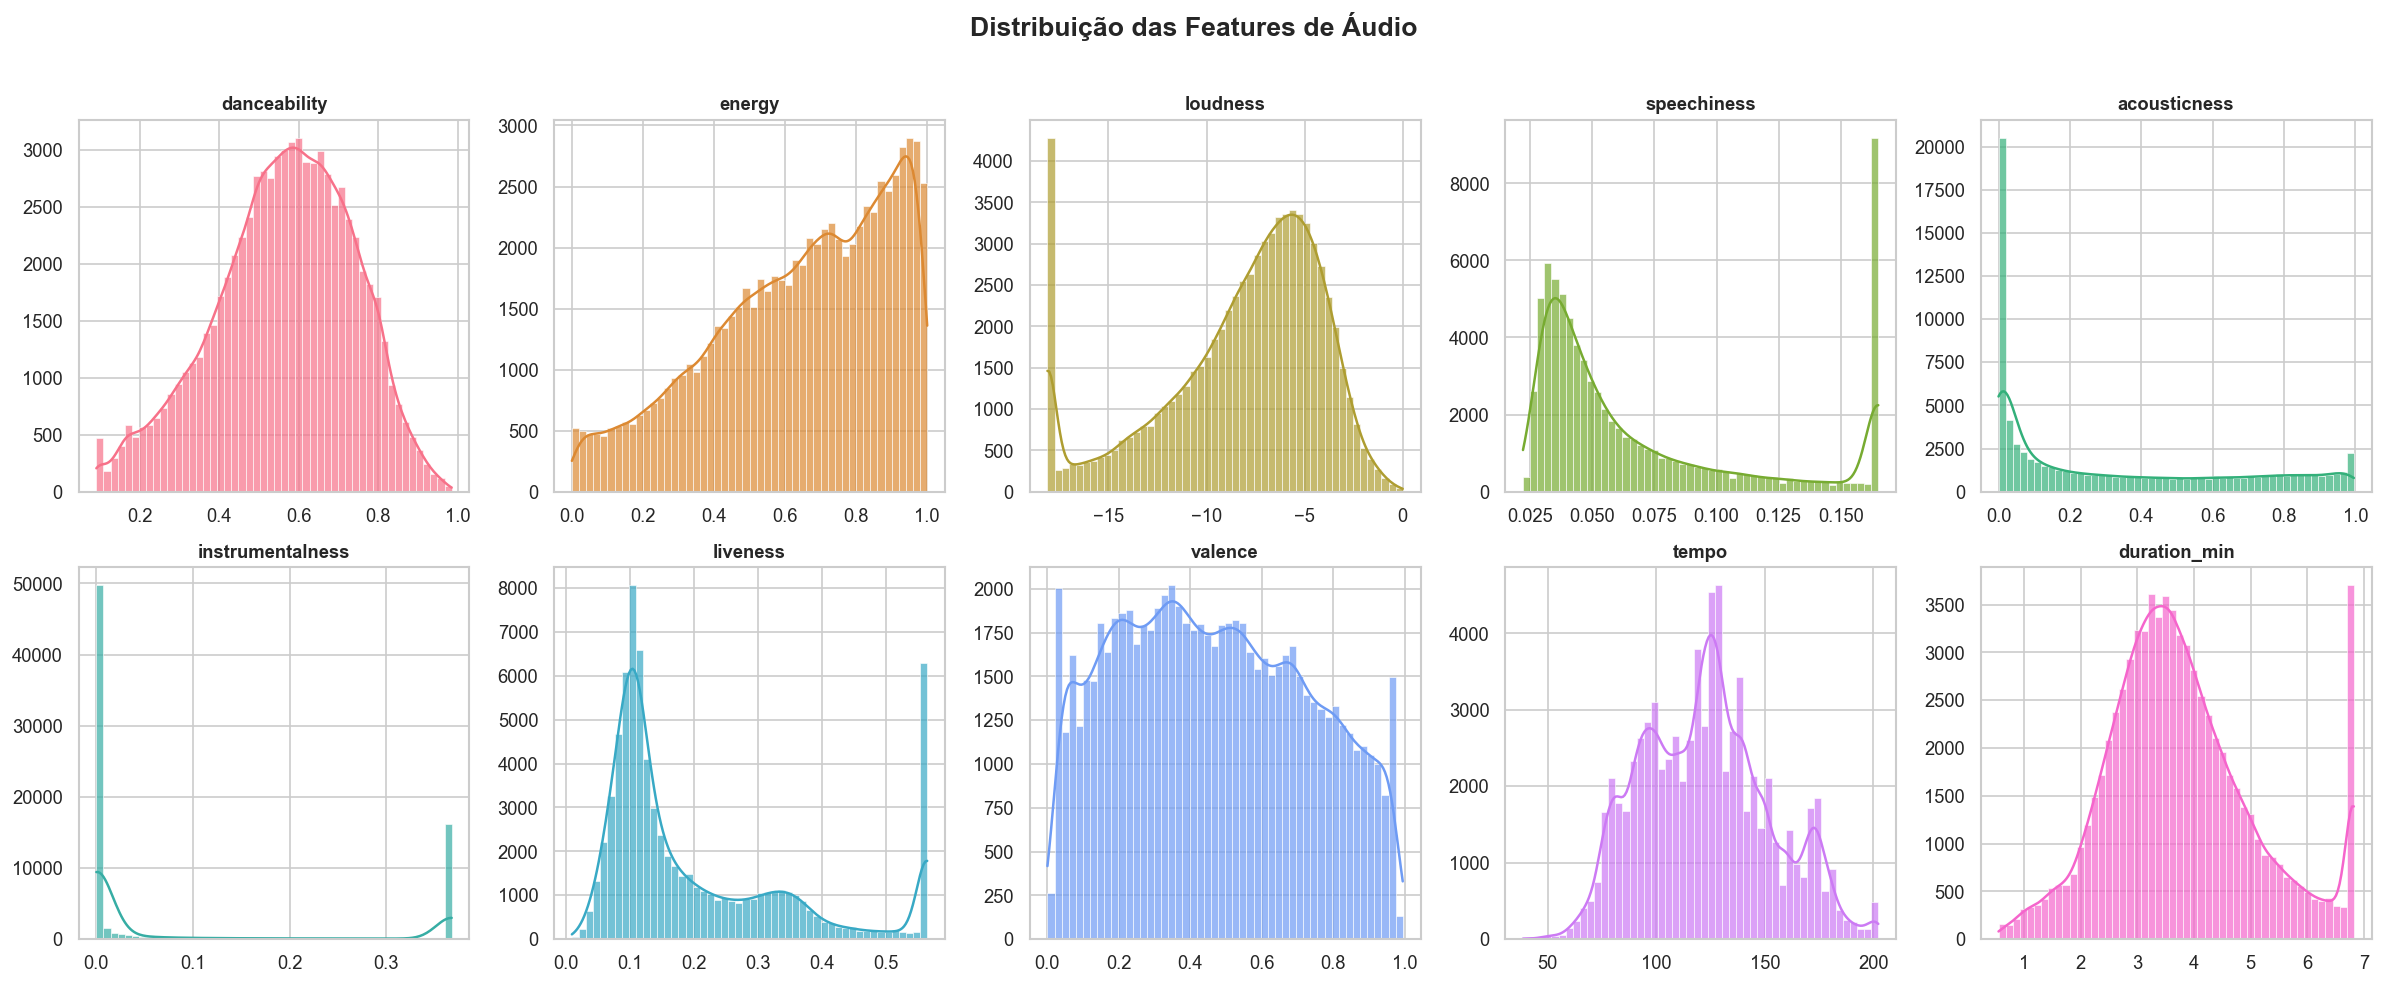

Gráfico salvo em resultados/11_distribuicao_features.png


In [4]:
# ============================================================
# 1.3 Distribuição das features de áudio
# ============================================================
print("=" * 72)
print("1.3 DISTRIBUIÇÃO DAS FEATURES DE ÁUDIO")
print("=" * 72)

# ------------------------------------------------------------
# Visualizar a distribuição de cada feature de áudio usando histogramas
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle(
    "Distribuição das Features de Áudio", fontsize=16, fontweight="bold", y=1.02
)

colors = sns.color_palette("husl", len(AUDIO_FEATURES))

for idx, (feature, ax) in enumerate(zip(AUDIO_FEATURES, axes.flatten())):
    sns.histplot(df[feature], ax=ax, color=colors[idx], kde=True, bins=50, alpha=0.7)
    ax.set_title(feature, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig("resultados/11_distribuicao_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo em resultados/11_distribuicao_features.png")

1.4 MATRIZ DE CORRELAÇÃO ENTRE FEATURES


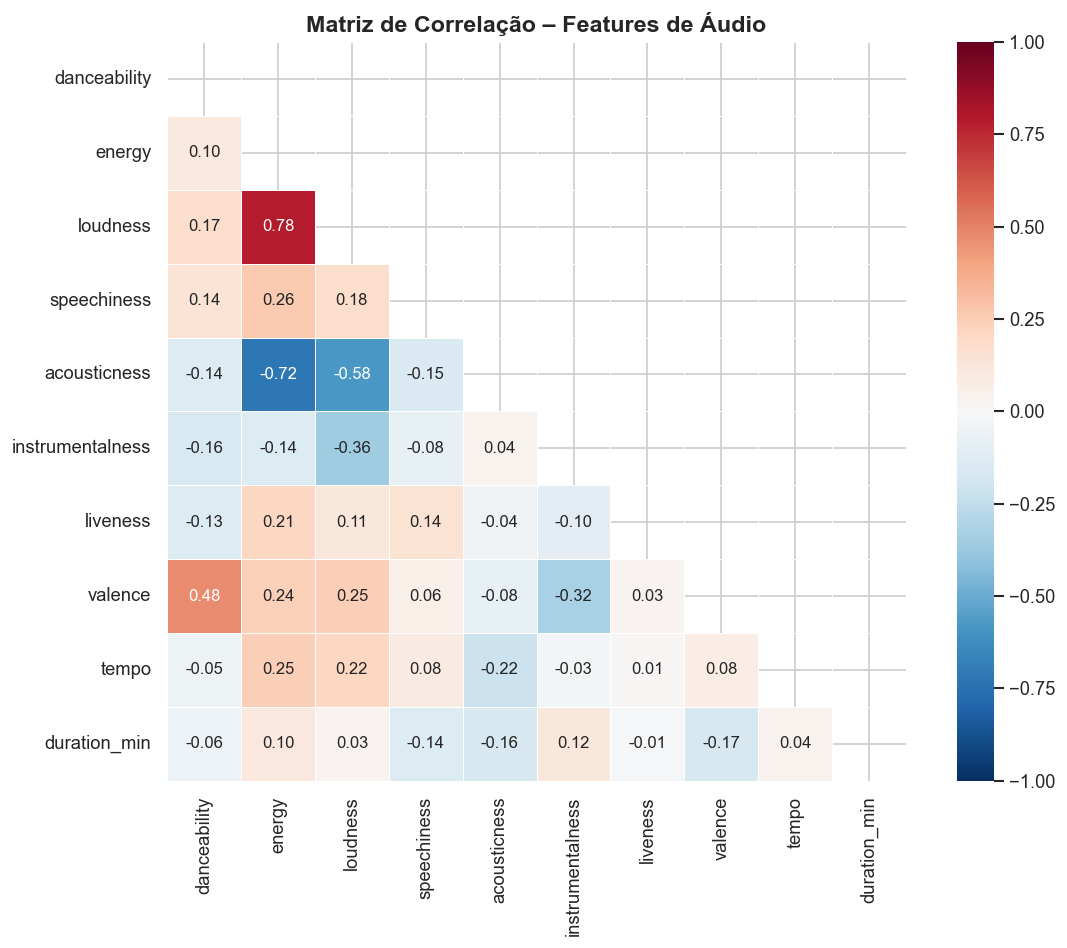

Gráfico salvo em resultados/12_correlacao_features.png

[1] Correlações mais fortes (|r| > 0.3):
  • danceability ↔ valence: 0.475
  • energy ↔ loudness: 0.782
  • energy ↔ acousticness: -0.724
  • loudness ↔ acousticness: -0.584
  • loudness ↔ instrumentalness: -0.358
  • instrumentalness ↔ valence: -0.321


In [5]:
# ============================================================
# 1.4 Matriz de correlação entre features
# ============================================================
print("=" * 72)
print("1.4 MATRIZ DE CORRELAÇÃO ENTRE FEATURES")
print("=" * 72)

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[AUDIO_FEATURES].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Matriz de Correlação – Features de Áudio", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("resultados/12_correlacao_features.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gráfico salvo em resultados/12_correlacao_features.png")

# Destacar correlações fortes
print("\n[1] Correlações mais fortes (|r| > 0.3):")
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.3:
            print(f"  • {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {val:.3f}")

---
## 2 - Preparação dos Dados para Modelagem

Antes de aplicar as técnicas de mineração, é necessário **padronizar** as features, pois elas possuem escalas diferentes. O `StandardScaler` transforma cada feature para média 0 e desvio padrão 1, conforme recomendado por Jain (2010) para algoritmos baseados em distância.

Posteriormente, a Análise de Componentes Principais (PCA) é usada para: 
(1) visualização 2D dos clusters, e
(2) remover ruído e correlações entre features. 

Segundo Jolliffe (2002), reter componentes que expliquem pelo menos 80% da variância é uma boa prática.

In [6]:
# ============================================================
# 2.1 Padronização (StandardScaler)
# ============================================================
print("=" * 72)
print("2.1 PADRONIZAÇÃO (STANDARDSCALER)")
print("=" * 72)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[AUDIO_FEATURES])

# Converter para DataFrame para facilitar manipulação
df_scaled = pd.DataFrame(X_scaled, columns=AUDIO_FEATURES, index=df.index)

print("[1] Padronização aplicada com StandardScaler")
print(f"\n[2] Shape dos dados padronizados: {X_scaled.shape}")
print(f"\n[3] Verificação (média ≈ 0, std ≈ 1):")
print(df_scaled.describe().loc[["mean", "std"]].round(4))

2.1 PADRONIZAÇÃO (STANDARDSCALER)
[1] Padronização aplicada com StandardScaler

[2] Shape dos dados padronizados: (75689, 10)

[3] Verificação (média ≈ 0, std ≈ 1):
      danceability  energy  loudness  speechiness  acousticness  \
mean           0.0     0.0       0.0         -0.0           0.0   
std            1.0     1.0       1.0          1.0           1.0   

      instrumentalness  liveness  valence  tempo  duration_min  
mean               0.0       0.0     -0.0    0.0          -0.0  
std                1.0       1.0      1.0    1.0           1.0  


2.2 REDUÇÃO DE DIMENSIONALIDADE COM PCA


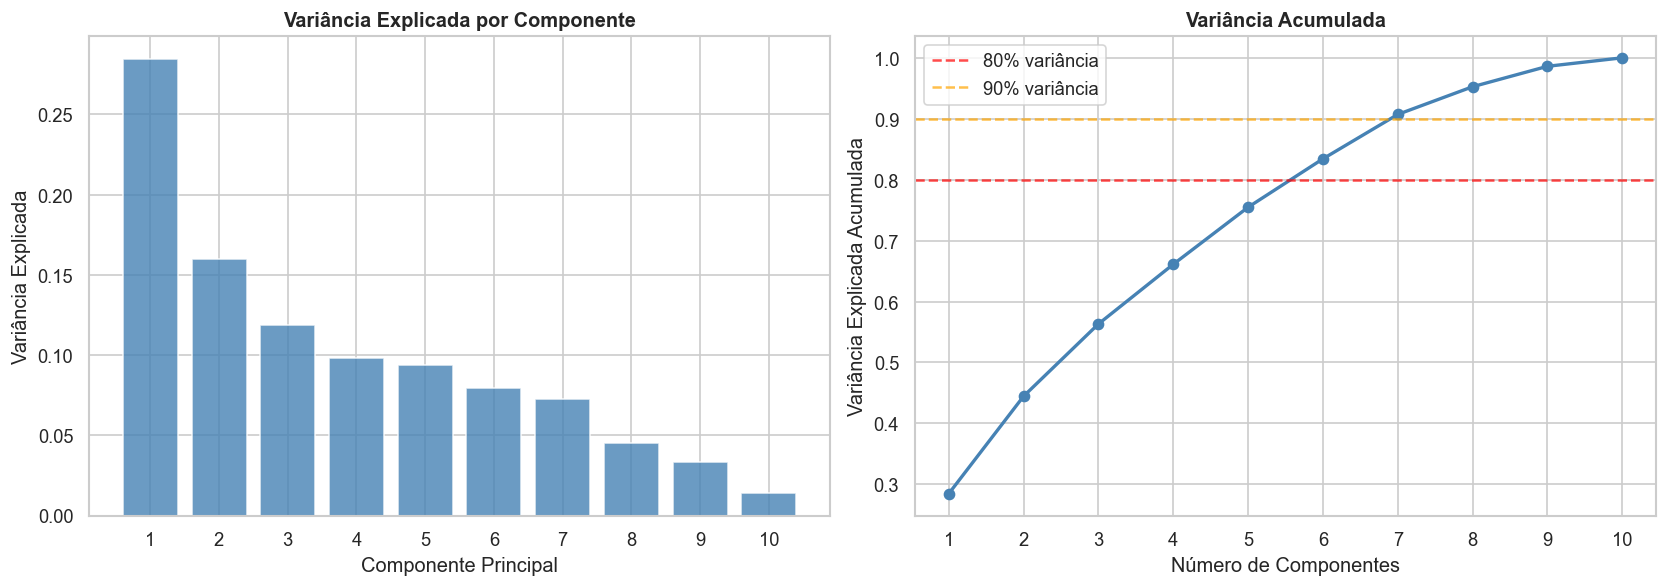


[1] Componentes mínimos por limiar de variância:
    80% da informação → 6 de 10 dimensões são suficientes
    90% da informação → 7 de 10 dimensões são suficientes
    Escolhemos 6 componentes: eliminamos 4 dimensão(ões) com baixa contribuição informacional

[2] PCA aplicado: 10 features originais → 6 componentes principais
    Cada música era descrita por 10 valores e agora 6 componentes representam o mesmo perfil sonoro

[3] Variância retida: 83.42%
    83.42% da informação original foi preservada, perdemos apenas 16.58% ao comprimir as dimensões


In [7]:
# ============================================================
# 2.2 Redução de Dimensionalidade com PCA
# ============================================================
print("=" * 72)
print("2.2 REDUÇÃO DE DIMENSIONALIDADE COM PCA")
print("=" * 72)

# Treina o PCA com todas as features para ver quanto cada componente explica
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

# Dois gráficos lado a lado: variância por componente e variância acumulada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Barras: quanto cada componente contribui individualmente para a variância total
ax1.bar(
    range(1, len(AUDIO_FEATURES) + 1),
    pca_full.explained_variance_ratio_,
    color="steelblue",
    alpha=0.8,
)
ax1.set_xlabel("Componente Principal")
ax1.set_ylabel("Variância Explicada")
ax1.set_title("Variância Explicada por Componente", fontweight="bold")
ax1.set_xticks(range(1, len(AUDIO_FEATURES) + 1))

# Linha acumulada: mostra quantos componentes são necessários para atingir 80% ou 90%
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
ax2.plot(
    range(1, len(AUDIO_FEATURES) + 1), cumvar, "o-", color="steelblue", linewidth=2
)
ax2.axhline(y=0.80, color="red", linestyle="--", alpha=0.7, label="80% variância")
ax2.axhline(y=0.90, color="orange", linestyle="--", alpha=0.7, label="90% variância")
ax2.set_xlabel("Número de Componentes")
ax2.set_ylabel("Variância Explicada Acumulada")
ax2.set_title("Variância Acumulada", fontweight="bold")
ax2.set_xticks(range(1, len(AUDIO_FEATURES) + 1))
ax2.legend()

plt.tight_layout()
plt.savefig("resultados/13_pca_variancia.png", dpi=150, bbox_inches="tight")
plt.show()

# Encontra o menor número de componentes que atinge 80% e 90% de variância
n_components_80 = np.argmax(cumvar >= 0.80) + 1
n_components_90 = np.argmax(cumvar >= 0.90) + 1

print(f"\n[1] Componentes mínimos por limiar de variância:")
print(
    f"    80% da informação → {n_components_80} de {len(AUDIO_FEATURES)} dimensões são suficientes"
)
print(
    f"    90% da informação → {n_components_90} de {len(AUDIO_FEATURES)} dimensões são suficientes"
)
print(
    f"    Escolhemos {n_components_80} componentes: eliminamos {len(AUDIO_FEATURES) - n_components_80} dimensão(ões) com baixa contribuição informacional"
)

# Aplica o PCA final reduzindo as features ao número mínimo de componentes necessários
N_COMPONENTS = n_components_80
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(
    f"\n[2] PCA aplicado: {X_scaled.shape[1]} features originais → {N_COMPONENTS} componentes principais"
)
print(
    f"    Cada música era descrita por {X_scaled.shape[1]} valores e agora {N_COMPONENTS} componentes representam o mesmo perfil sonoro"
)

print(f"\n[3] Variância retida: {pca.explained_variance_ratio_.sum():.2%}")
print(
    f"    {pca.explained_variance_ratio_.sum():.2%} da informação original foi preservada, perdemos apenas {1 - pca.explained_variance_ratio_.sum():.2%} ao comprimir as dimensões"
)

---
## 3 - KMeans Clustering

O **KMeans** é um algoritmo de particionamento que divide os dados em $k$ clusters, minimizando a soma das distâncias ao quadrado entre cada ponto e o centróide do seu cluster (inércia). Segundo Arthur & Vassilvitskii (2007), a inicialização **k-means++** melhora significativamente a convergência.

O objetivo desta etapa é identificar **perfis sonoros** naturais no catálogo do Spotify, agrupando músicas com características acústicas semelhantes. Esses clusters serão utilizados **exclusivamente na Técnica 1** de recomendação (KMeans + Distância Euclidiana). A Técnica 2 (Similaridade de Cosseno) é independente e não utiliza clusters.

### Parâmetros

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| `n_clusters` | **7** (determinado por Silhouette Score + Sensibilidade) | Maior K com score elevado antes da queda |
| `init` | `k-means++` | Inicialização inteligente (Arthur & Vassilvitskii, 2007) |
| `n_init` | 10 | Múltiplas inicializações para robustez |
| `max_iter` | 300 | Convergência garantida |
| `random_state` | 42 | Reprodutibilidade |

3.1 DETERMINAÇÃO DO NÚMERO ÓTIMO DE CLUSTERS
    Elbow Method + Silhouette Score + Análise de Sensibilidade
[1] Testando valores de k de 2 a 10...

  k= 2 | Inércia:      483,391 | Silhouette: 0.2481
  k= 3 | Inércia:      419,580 | Silhouette: 0.1772
  k= 4 | Inércia:      378,975 | Silhouette: 0.1772
  k= 5 | Inércia:      348,247 | Silhouette: 0.1692
  k= 6 | Inércia:      319,696 | Silhouette: 0.1736
  k= 7 | Inércia:      296,963 | Silhouette: 0.1779
  k= 8 | Inércia:      281,723 | Silhouette: 0.1658
  k= 9 | Inércia:      268,390 | Silhouette: 0.1654
  k=10 | Inércia:      259,015 | Silhouette: 0.1664


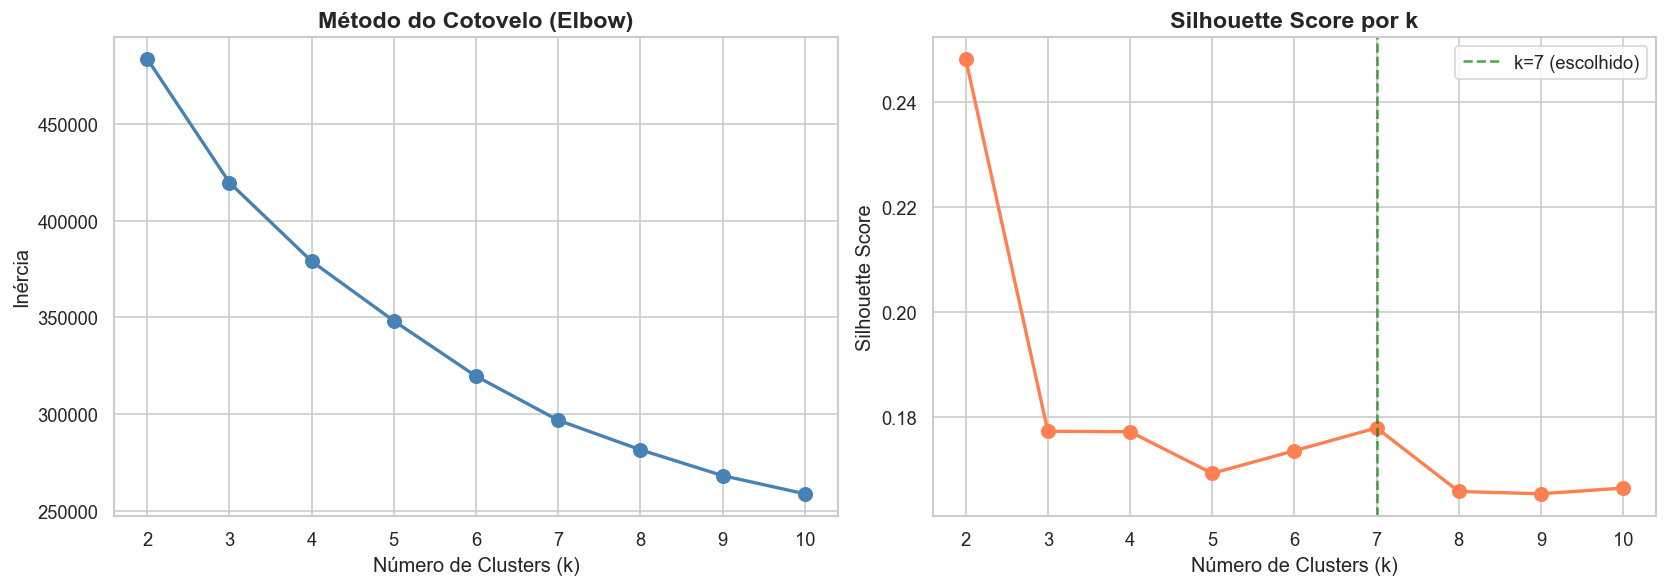


[2] Comparação de Silhouette Score por K:

      K |   Silhouette | Observação
    ----+--------------+--------------------------------------------------------
      2 |       0.2481 | Maior score absoluto, mas apenas 2 grupos (genérico demais)
      3 |       0.1772 | Score alto, mas poucos clusters — perde nuances entre perfis
      4 |       0.1772 | Razoável, clusters ainda muito abrangentes
      5 |       0.1692 | Bom equilíbrio, mas variabilidade limitada a 5 perfis
      6 |       0.1736 | Boa granularidade, score competitivo
      7 |       0.1779 | ★ ESCOLHIDO: maior K com score alto antes da queda ◀
      8 |       0.1658 | Início da queda significativa no score
      9 |       0.1654 | Score em declínio — fragmentação excessiva
     10 |       0.1664 | Score baixo — clusters perdem identidade clara


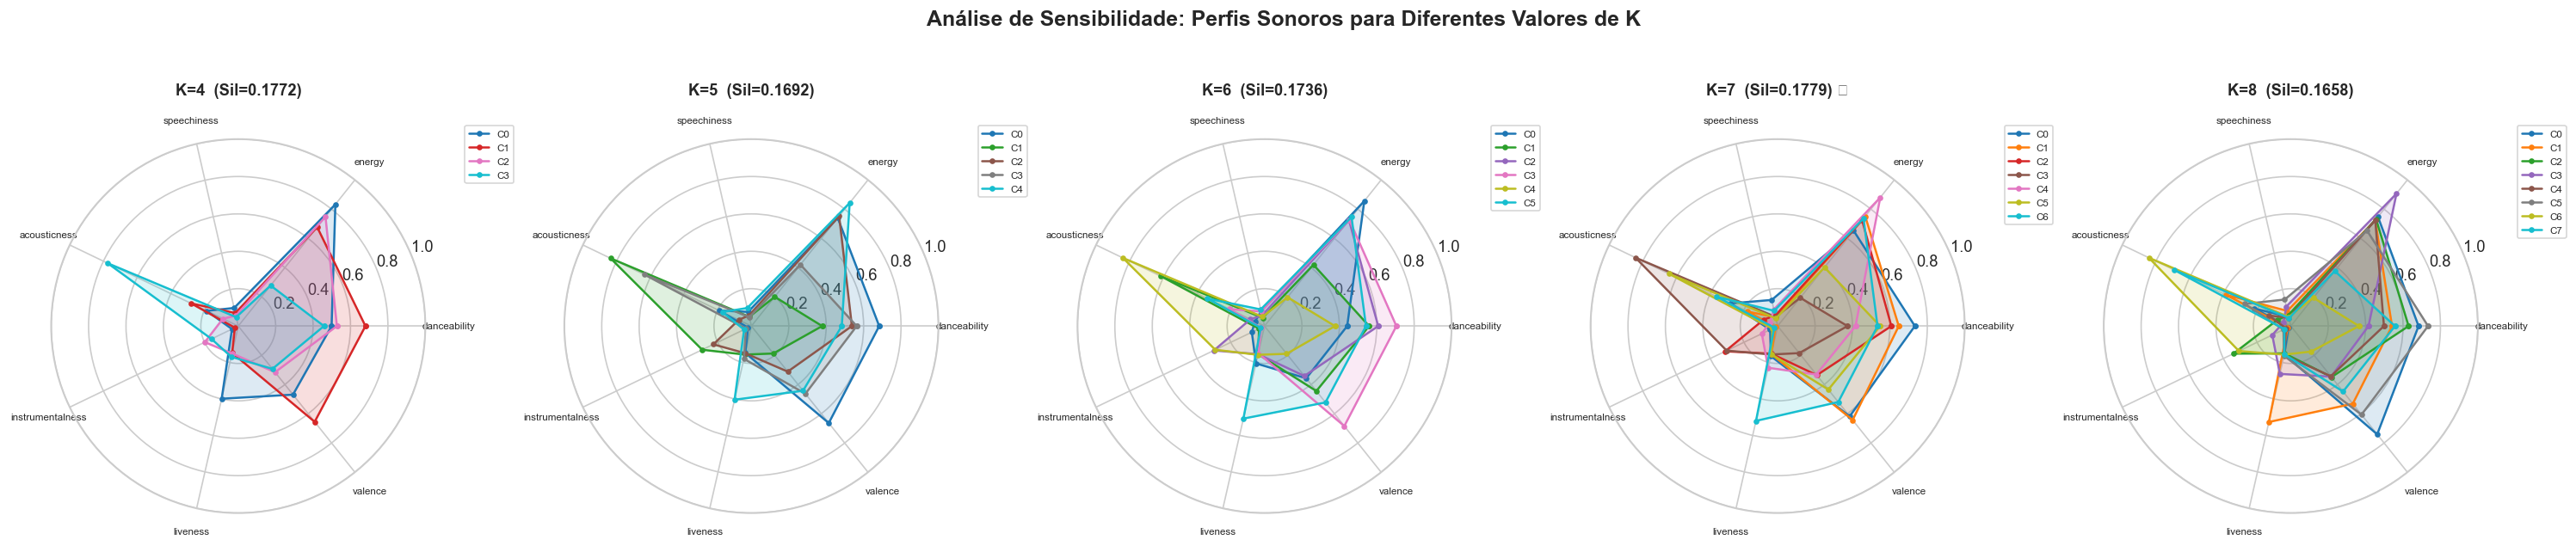


[3] Justificativa para K=7:
    • Silhouette Score de K=7: 0.1779
    • Valores mais próximos de 1 indicam melhor separação entre clusters
    • K=7 é o MAIOR número de clusters com score elevado antes da queda (K≥8)
    • Maior K → maior variabilidade de perfis sonoros com qualidade mantida
    • K menores (2–6): scores similares ou maiores, mas menor granularidade
    • K maiores (8–10): queda acentuada no score → fragmentação sem ganho
    ⇒ K=7 maximiza a granularidade mantendo boa qualidade de separação


In [26]:
# ============================================================
# 3.1 Determinação do número ótimo de clusters
#     (Elbow Method + Silhouette Score + Análise de Sensibilidade)
# ============================================================
print("=" * 72)
print("3.1 DETERMINAÇÃO DO NÚMERO ÓTIMO DE CLUSTERS")
print("    Elbow Method + Silhouette Score + Análise de Sensibilidade")
print("=" * 72)

K_RANGE = range(2, 11)
inertias = []
silhouette_scores = []

print("[1] Testando valores de k de 2 a 10...\n")
for k in K_RANGE:
    kmeans_temp = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE,
    )
    labels_temp = kmeans_temp.fit_predict(X_pca)
    inertias.append(kmeans_temp.inertia_)
    sil_score = silhouette_score(
        X_pca, labels_temp, sample_size=10000, random_state=RANDOM_STATE
    )
    silhouette_scores.append(sil_score)
    print(
        f"  k={k:2d} | Inércia: {kmeans_temp.inertia_:>12,.0f} | Silhouette: {sil_score:.4f}"
    )

# ---- Gráfico 1: Elbow + Silhouette ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_RANGE, inertias, "o-", color="steelblue", linewidth=2, markersize=8)
ax1.set_xlabel("Número de Clusters (k)", fontsize=12)
ax1.set_ylabel("Inércia", fontsize=12)
ax1.set_title("Método do Cotovelo (Elbow)", fontsize=14, fontweight="bold")
ax1.set_xticks(list(K_RANGE))

ax2.plot(K_RANGE, silhouette_scores, "o-", color="coral", linewidth=2, markersize=8)
ax2.axvline(x=7, color="green", linestyle="--", alpha=0.7, label="k=7 (escolhido)")
ax2.set_xlabel("Número de Clusters (k)", fontsize=12)
ax2.set_ylabel("Silhouette Score", fontsize=12)
ax2.set_title("Silhouette Score por k", fontsize=14, fontweight="bold")
ax2.set_xticks(list(K_RANGE))
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig("resultados/14_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Tabela comparativa de Silhouette Score ----
print("\n[2] Comparação de Silhouette Score por K:\n")
print(f"    {'K':>3} | {'Silhouette':>12} | Observação")
print(f"    {'-'*3}-+-{'-'*12}-+-{'-'*55}")
for k_val, sil in zip(K_RANGE, silhouette_scores):
    obs = ""
    if k_val == 2:
        obs = "Maior score absoluto, mas apenas 2 grupos (genérico demais)"
    elif k_val == 3:
        obs = "Score alto, mas poucos clusters — perde nuances entre perfis"
    elif k_val == 4:
        obs = "Razoável, clusters ainda muito abrangentes"
    elif k_val == 5:
        obs = "Bom equilíbrio, mas variabilidade limitada a 5 perfis"
    elif k_val == 6:
        obs = "Boa granularidade, score competitivo"
    elif k_val == 7:
        obs = "★ ESCOLHIDO: maior K com score alto antes da queda"
    elif k_val == 8:
        obs = "Início da queda significativa no score"
    elif k_val == 9:
        obs = "Score em declínio — fragmentação excessiva"
    elif k_val == 10:
        obs = "Score baixo — clusters perdem identidade clara"
    marker = " ◀" if k_val == 7 else ""
    print(f"    {k_val:>3} | {sil:>12.4f} | {obs}{marker}")

# ---- Gráfico 2: Radar de sensibilidade para K candidatos ----
k_candidates = [4, 5, 6, 7, 8]

fig, axes = plt.subplots(
    1,
    len(k_candidates),
    figsize=(5 * len(k_candidates), 5),
    subplot_kw=dict(polar=True),
)

radar_feats = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
]
num_vars = len(radar_feats)
angles_r = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles_r += angles_r[:1]

sil_results = {}

for i, k in enumerate(k_candidates):
    km_temp = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE,
    )
    labels_temp = km_temp.fit_predict(X_pca)
    sil_temp = silhouette_score(
        X_pca, labels_temp, sample_size=10000, random_state=RANDOM_STATE
    )
    sil_results[k] = sil_temp

    ax = axes[i]
    colors_k = plt.cm.tab10(np.linspace(0, 1, k))

    for c in range(k):
        cluster_mask_temp = labels_temp == c
        profile = df.loc[cluster_mask_temp, radar_feats].mean().values.tolist()
        profile += profile[:1]
        ax.fill(angles_r, profile, alpha=0.15, color=colors_k[c])
        ax.plot(
            angles_r,
            profile,
            "o-",
            color=colors_k[c],
            linewidth=1.5,
            markersize=3,
            label=f"C{c}",
        )

    ax.set_xticks(angles_r[:-1])
    ax.set_xticklabels(radar_feats, fontsize=7)
    ax.set_ylim(0, 1)
    star = " ★" if k == 7 else ""
    ax.set_title(
        f"K={k}  (Sil={sil_temp:.4f}){star}",
        fontsize=11,
        fontweight="bold",
        pad=15,
    )
    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05), fontsize=7)

fig.suptitle(
    "Análise de Sensibilidade: Perfis Sonoros para Diferentes Valores de K",
    fontsize=15,
    fontweight="bold",
    y=1.05,
)
plt.tight_layout()
plt.savefig("resultados/14b_validacao_k.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Justificativa final para K=7 ----
best_k = 7
sil_k7 = silhouette_scores[5]  # index 5 = k=7 (range começa em 2)

print(f"\n[3] Justificativa para K={best_k}:")
print(f"    • Silhouette Score de K=7: {sil_k7:.4f}")
print(f"    • Valores mais próximos de 1 indicam melhor separação entre clusters")
print(f"    • K=7 é o MAIOR número de clusters com score elevado antes da queda (K≥8)")
print(f"    • Maior K → maior variabilidade de perfis sonoros com qualidade mantida")
print(f"    • K menores (2–6): scores similares ou maiores, mas menor granularidade")
print(f"    • K maiores (8–10): queda acentuada no score → fragmentação sem ganho")
print(f"    ⇒ K=7 maximiza a granularidade mantendo boa qualidade de separação")

In [27]:
# ============================================================
# 3.2 Treinamento do KMeans com k ótimo
# ============================================================
print("=" * 72)
print("3.2 TREINAMENTO DO KMEANS COM K ÓTIMO")
print("=" * 72)

OPTIMAL_K = 7

print(f"[1] K escolhido: {OPTIMAL_K}")
print(f"    Baseado na análise conjunta (seção 3.1):")
print(f"    - Silhouette Score: K=7 é o maior K com score elevado antes da queda (K≥8)")
print(f"    - Análise de sensibilidade: 7 perfis sonoros distintos nos radars")
print(f"    - Elbow Method: inflexão da inércia compatível com K=7")
print(f"    - Maior granularidade que K=5 ou K=6 sem perda de qualidade")

print(f"\n[2] Treinando KMeans com k = {OPTIMAL_K}...")

kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=RANDOM_STATE,
)

df["cluster"] = kmeans.fit_predict(X_pca)

print(f"\n[3] Clustering concluído!")

print(f"\n[4] Distribuição dos clusters:")
cluster_counts = df["cluster"].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = count / len(df) * 100
    print(f"    Cluster {cluster_id}: {count:>6,} músicas ({pct:.1f}%)")

final_sil = silhouette_score(
    X_pca, df["cluster"], sample_size=10000, random_state=RANDOM_STATE
)
print(f"\n[5] Silhouette Score final (k={OPTIMAL_K}): {final_sil:.4f}")
print(
    f"    Score entre 0 e 1 — quanto mais próximo de 1, melhor a separação dos clusters"
)

3.2 TREINAMENTO DO KMEANS COM K ÓTIMO
[1] K escolhido: 7
    Baseado na análise conjunta (seção 3.1):
    - Silhouette Score: K=7 é o maior K com score elevado antes da queda (K≥8)
    - Análise de sensibilidade: 7 perfis sonoros distintos nos radars
    - Elbow Method: inflexão da inércia compatível com K=7
    - Maior granularidade que K=5 ou K=6 sem perda de qualidade

[2] Treinando KMeans com k = 7...

[3] Clustering concluído!

[4] Distribuição dos clusters:
    Cluster 0:  8,655 músicas (11.4%)
    Cluster 1: 18,529 músicas (24.5%)
    Cluster 2:  8,305 músicas (11.0%)
    Cluster 3:  6,839 músicas (9.0%)
    Cluster 4: 11,757 músicas (15.5%)
    Cluster 5: 13,885 músicas (18.3%)
    Cluster 6:  7,719 músicas (10.2%)

[5] Silhouette Score final (k=7): 0.1779
    Score entre 0 e 1 — quanto mais próximo de 1, melhor a separação dos clusters


3.3 VISUALIZAÇÃO DOS CLUSTERS COM PCA 2D


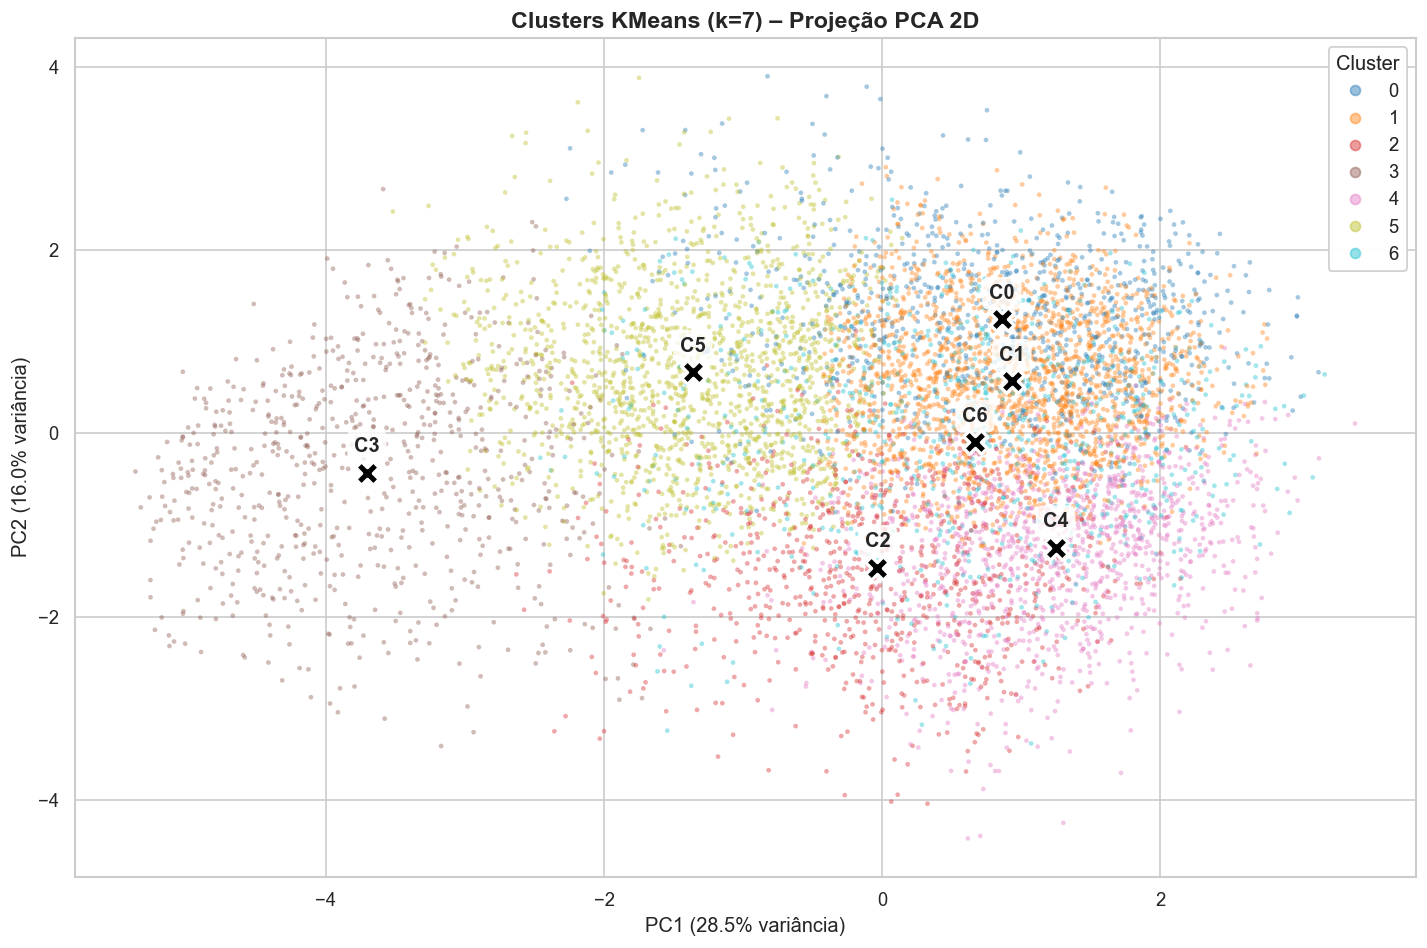


[1] Variância explicada pela projeção 2D: 44.45%
    As 6 dimensões do PCA foram reduzidas a 2 apenas para visualização no plano cartesiano


In [28]:
# ============================================================
# 3.3 Visualização dos clusters com PCA 2D
# ============================================================
print("=" * 72)
print("3.3 VISUALIZAÇÃO DOS CLUSTERS COM PCA 2D")
print("=" * 72)

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))

# Amostra de 8.000 pontos para performance
sample_idx = np.random.choice(len(df), size=min(8000, len(df)), replace=False)

scatter = ax.scatter(
    X_2d[sample_idx, 0],
    X_2d[sample_idx, 1],
    c=df["cluster"].values[sample_idx],
    cmap="tab10",
    alpha=0.4,
    s=8,
    edgecolors="none",
)

centroids_2d = pca_2d.transform(
    scaler.inverse_transform(pca.inverse_transform(kmeans.cluster_centers_)).reshape(
        OPTIMAL_K, -1
    )
)

# Centróides posicionados pela média de cada cluster
for c in range(OPTIMAL_K):
    mask = df["cluster"].values == c
    cx, cy = X_2d[mask, 0].mean(), X_2d[mask, 1].mean()
    ax.scatter(
        cx, cy, c="black", marker="X", s=200, edgecolors="white", linewidth=2, zorder=5
    )
    ax.annotate(
        f"C{c}",
        (cx, cy),
        fontsize=12,
        fontweight="bold",
        ha="center",
        va="bottom",
        xytext=(0, 10),
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variância)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variância)", fontsize=12)
ax.set_title(
    f"Clusters KMeans (k={OPTIMAL_K}) – Projeção PCA 2D", fontsize=14, fontweight="bold"
)

legend = ax.legend(*scatter.legend_elements(), title="Cluster", loc="upper right")
ax.add_artist(legend)

plt.tight_layout()
plt.savefig("resultados/15_clusters_pca2d.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    f"\n[1] Variância explicada pela projeção 2D: {pca_2d.explained_variance_ratio_.sum():.2%}"
)
print(
    f"    As {N_COMPONENTS} dimensões do PCA foram reduzidas a 2 apenas para visualização no plano cartesiano"
)

3.4 PERFIL SONORO DOS CLUSTERS - HEATMAP


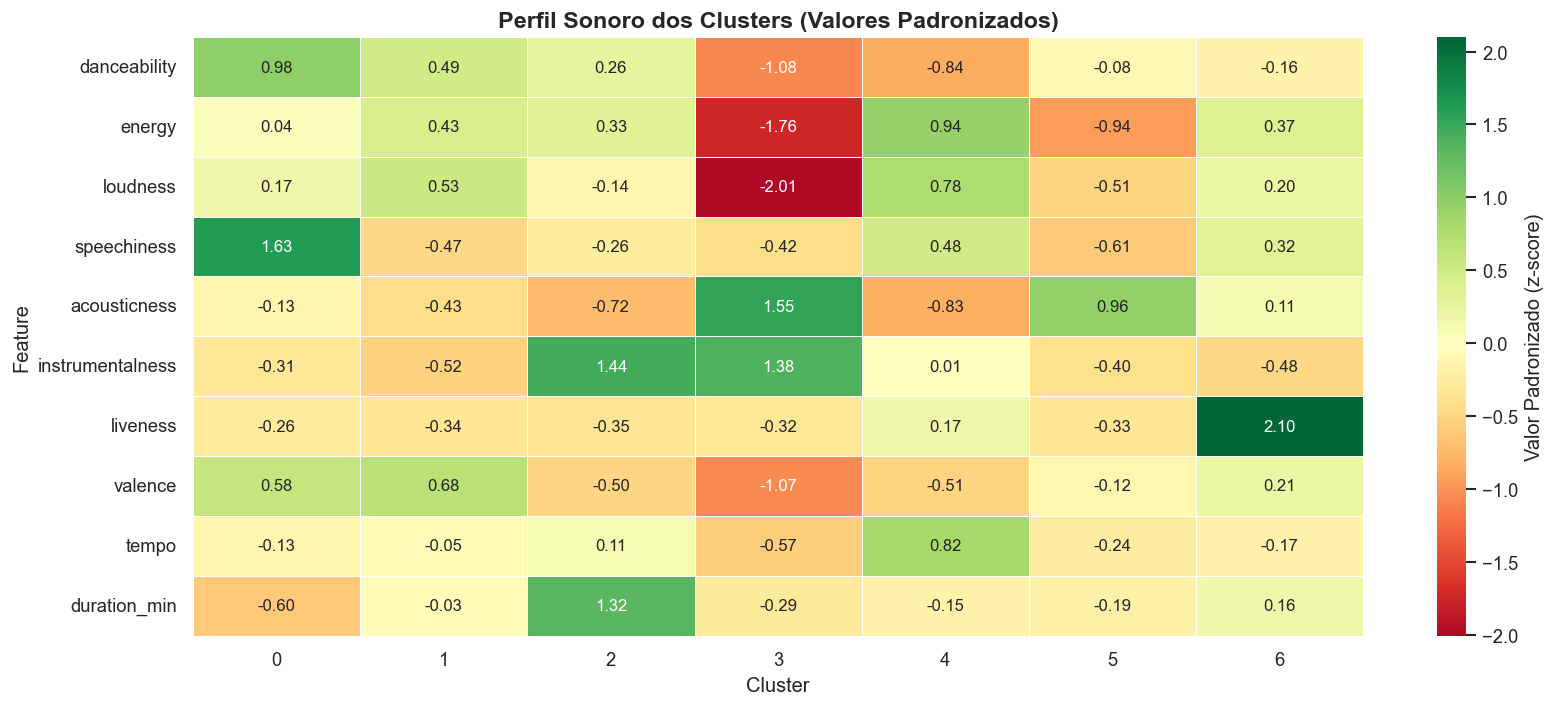

In [29]:
# ============================================================
# 3.4 Perfil sonoro de cada cluster (Heatmap)
# ============================================================
print("=" * 72)
print("3.4 PERFIL SONORO DOS CLUSTERS - HEATMAP")
print("=" * 72)

df_scaled["cluster"] = df["cluster"].values
cluster_profiles = df_scaled.groupby("cluster")[AUDIO_FEATURES].mean()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    cluster_profiles.T,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Valor Padronizado (z-score)"},
)
ax.set_title(
    "Perfil Sonoro dos Clusters (Valores Padronizados)", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Cluster", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)

plt.tight_layout()
plt.savefig("resultados/16_cluster_profiles_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

3.5 RADAR CHART - PERFIL SONORO POR CLUSTER


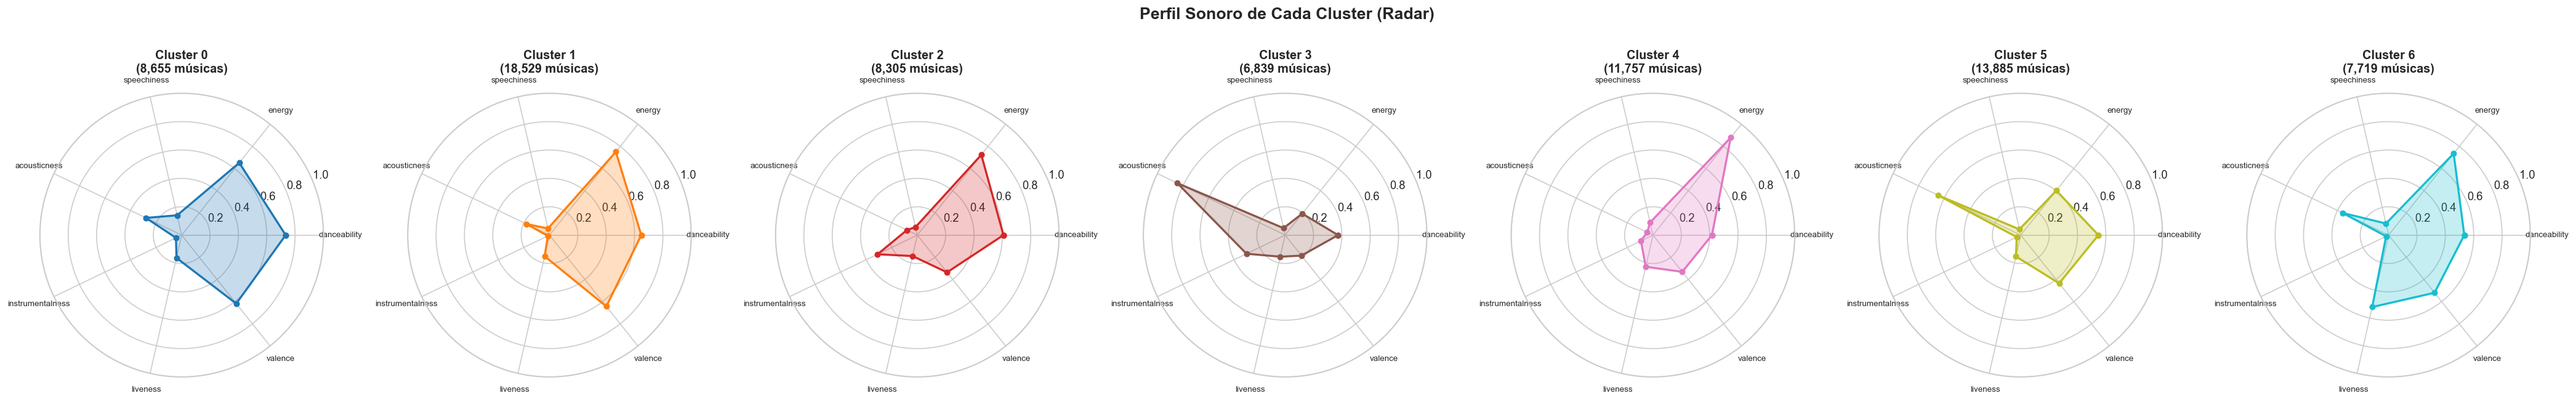

In [30]:
# ============================================================
# 3.5 Radar Chart - Perfil de cada cluster
# ============================================================
print("=" * 72)
print("3.5 RADAR CHART - PERFIL SONORO POR CLUSTER")
print("=" * 72)

from sklearn.preprocessing import MinMaxScaler

radar_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
]

cluster_radar = df.groupby("cluster")[radar_features].mean()

num_vars = len(radar_features)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(
    1, OPTIMAL_K, figsize=(5 * OPTIMAL_K, 5), subplot_kw=dict(polar=True)
)
if OPTIMAL_K == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 1, OPTIMAL_K))

for idx, (cluster_id, row) in enumerate(cluster_radar.iterrows()):
    ax = axes[idx]
    values = row.tolist()
    values += values[:1]

    ax.fill(angles, values, color=colors[idx], alpha=0.25)
    ax.plot(angles, values, "o-", color=colors[idx], linewidth=2, markersize=5)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_features, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(
        f"Cluster {cluster_id}\n({cluster_counts[cluster_id]:,} músicas)",
        fontsize=12,
        fontweight="bold",
        pad=20,
    )

fig.suptitle(
    "Perfil Sonoro de Cada Cluster (Radar)", fontsize=16, fontweight="bold", y=1.05
)
plt.tight_layout()
plt.savefig("resultados/17_cluster_radar.png", dpi=150, bbox_inches="tight")
plt.show()

3.6 GÊNEROS PREDOMINANTES POR CLUSTER
Top 5 gêneros por cluster:

  Cluster 0 (8,655 músicas):
    - kids: 519 (6.0%)
    - dancehall: 488 (5.6%)
    - j-dance: 462 (5.3%)
    - study: 330 (3.8%)
    - funk: 309 (3.6%)

  Cluster 1 (18,529 músicas):
    - forro: 591 (3.2%)
    - salsa: 586 (3.2%)
    - j-idol: 462 (2.5%)
    - deep-house: 426 (2.3%)
    - ska: 403 (2.2%)

  Cluster 2 (8,305 músicas):
    - detroit-techno: 748 (9.0%)
    - minimal-techno: 729 (8.8%)
    - chicago-house: 637 (7.7%)
    - breakbeat: 444 (5.3%)
    - idm: 409 (4.9%)

  Cluster 3 (6,839 músicas):
    - new-age: 771 (11.3%)
    - ambient: 645 (9.4%)
    - sleep: 558 (8.2%)
    - disney: 503 (7.4%)
    - piano: 414 (6.1%)

  Cluster 4 (11,757 músicas):
    - grindcore: 857 (7.3%)
    - death-metal: 631 (5.4%)
    - hardstyle: 561 (4.8%)
    - black-metal: 538 (4.6%)
    - happy: 499 (4.2%)

  Cluster 5 (13,885 músicas):
    - honky-tonk: 674 (4.9%)
    - cantopop: 646 (4.7%)
    - tango: 594 (4.3%)
    - acou

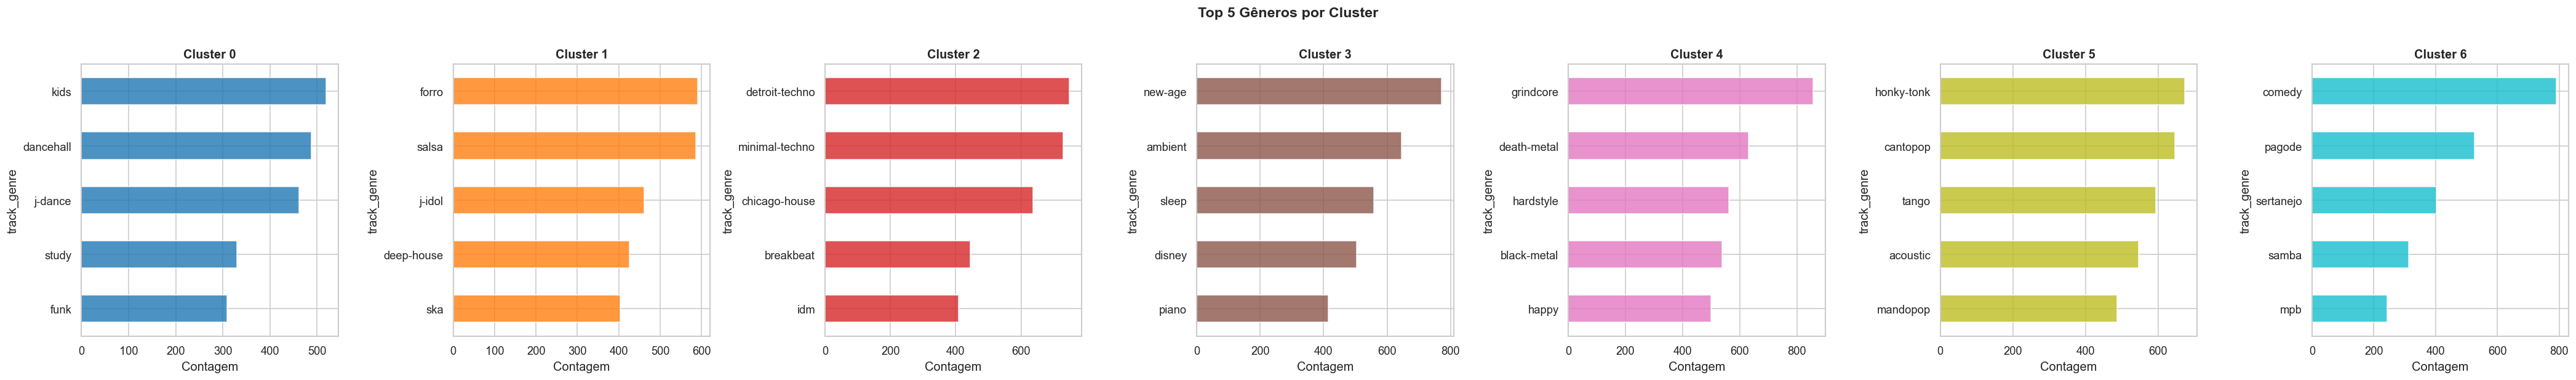

In [31]:
# ============================================================
# 3.6 Gêneros predominantes por cluster
# ============================================================
print("=" * 72)
print("3.6 GÊNEROS PREDOMINANTES POR CLUSTER")
print("=" * 72)

print("Top 5 gêneros por cluster:\n")

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(5 * OPTIMAL_K, 5))
if OPTIMAL_K == 1:
    axes = [axes]

for cluster_id in range(OPTIMAL_K):
    cluster_data = df[df["cluster"] == cluster_id]
    top_genres = cluster_data["track_genre"].value_counts().head(5)

    print(f"  Cluster {cluster_id} ({len(cluster_data):,} músicas):")
    for genre, count in top_genres.items():
        pct = count / len(cluster_data) * 100
        print(f"    - {genre}: {count} ({pct:.1f}%)")
    print()

    ax = axes[cluster_id]
    top_genres.plot(kind="barh", ax=ax, color=colors[cluster_id], alpha=0.8)
    ax.set_title(f"Cluster {cluster_id}", fontweight="bold")
    ax.set_xlabel("Contagem")
    ax.invert_yaxis()

fig.suptitle("Top 5 Gêneros por Cluster", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("resultados/18_generos_por_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.7 Interpretação dos Clusters

Com **K=7** clusters, o KMeans identifica **sete perfis sonoros** distintos no catálogo do Spotify. A escolha de 7 clusters (justificada em 3.1 pela análise de Silhouette Score) permite capturar nuances adicionais em relação a K menores — por exemplo, distinguir subgêneros eletrônicos, separar perfis acústicos instrumentais de vocais, e identificar nichos como comedy/spoken-word.

A célula abaixo gera automaticamente a interpretação de cada cluster com base nos valores médios padronizados (z-score) de cada feature e nos gêneros predominantes. Os perfis visuais podem ser conferidos no heatmap (3.4) e nos radar charts (3.5).

In [32]:
# ============================================================
# 3.7 Interpretação Automática dos Clusters
# ============================================================
print("=" * 72)
print(f"3.7 INTERPRETAÇÃO AUTOMÁTICA DOS CLUSTERS (K={OPTIMAL_K})")
print("=" * 72)

df_scaled["cluster"] = df["cluster"].values
cluster_profiles = df_scaled.groupby("cluster")[AUDIO_FEATURES].mean()

for cid in range(OPTIMAL_K):
    count = cluster_counts[cid]
    pct_c = count / len(df) * 100
    prof = cluster_profiles.loc[cid]

    # Features dominantes (positivas e negativas)
    top_pos = prof.nlargest(3)
    top_neg = prof.nsmallest(3)

    # Gêneros predominantes
    cdata = df[df["cluster"] == cid]
    top_gen = cdata["track_genre"].value_counts().head(5)

    print(f"\n{'─' * 60}")
    print(f"  CLUSTER {cid} — {count:,} músicas ({pct_c:.1f}%)")
    print(f"{'─' * 60}")

    print(f"  Features DOMINANTES (z-score positivo alto):")
    for feat, val in top_pos.items():
        if val > 0.2:
            print(f"    ▲ {feat}: {val:+.2f}")

    print(f"  Features RECUADAS (z-score negativo):")
    for feat, val in top_neg.items():
        if val < -0.2:
            print(f"    ▼ {feat}: {val:+.2f}")

    print(f"  Top 5 gêneros: {', '.join(top_gen.index.tolist())}")

print(f"\n{'=' * 60}")
print(f"Síntese: Os {OPTIMAL_K} clusters formam um espectro sonoro diversificado,")
print(f"capturando perfis desde dançantes/energéticos até acústicos/introspectivos.")
print(f"A granularidade com K={OPTIMAL_K} distingue nuances que K menores perderiam.")

3.7 INTERPRETAÇÃO AUTOMÁTICA DOS CLUSTERS (K=7)

────────────────────────────────────────────────────────────
  CLUSTER 0 — 8,655 músicas (11.4%)
────────────────────────────────────────────────────────────
  Features DOMINANTES (z-score positivo alto):
    ▲ speechiness: +1.63
    ▲ danceability: +0.98
    ▲ valence: +0.58
  Features RECUADAS (z-score negativo):
    ▼ duration_min: -0.60
    ▼ instrumentalness: -0.31
    ▼ liveness: -0.26
  Top 5 gêneros: kids, dancehall, j-dance, study, funk

────────────────────────────────────────────────────────────
  CLUSTER 1 — 18,529 músicas (24.5%)
────────────────────────────────────────────────────────────
  Features DOMINANTES (z-score positivo alto):
    ▲ valence: +0.68
    ▲ loudness: +0.53
    ▲ danceability: +0.49
  Features RECUADAS (z-score negativo):
    ▼ instrumentalness: -0.52
    ▼ speechiness: -0.47
    ▼ acousticness: -0.43
  Top 5 gêneros: forro, salsa, j-idol, deep-house, ska

────────────────────────────────────────────────

---
## 4 - Técnica 1: Recomendação por KMeans (Distância Euclidiana)

> **Esta técnica UTILIZA os clusters KMeans** — diferentemente da Técnica 2 (Cosseno), que é independente.

Nesta técnica, utilizamos o modelo KMeans já treinado (K=7) para **recomendar músicas**:

1. **Identificar o cluster** da música de referência (atribuído pelo KMeans);
2. **Filtrar** todas as músicas pertencentes ao **mesmo cluster**;
3. **Ordenar** por **distância Euclidiana** dentro do cluster — quanto menor a distância, mais semelhante.

A **Distância Euclidiana** mede a distância em linha reta entre dois pontos no espaço de features:

$$d(A, B) = \sqrt{\sum_{i=1}^{n} (a_i - b_i)^2}$$

Ao restringir a busca ao cluster, reduzimos o espaço de busca e garantimos que as recomendações pertencem ao mesmo **perfil sonoro** identificado pelo KMeans. A ordenação por distância Euclidiana encontra as músicas numericamente mais próximas dentro desse grupo (Aggarwal, 2016).

> **Nota:** A distância Euclidiana é a métrica natural e coerente com o próprio algoritmo KMeans, que minimiza a soma dos quadrados das distâncias (inércia).

### Parâmetros
| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| Entrada | Features padronizadas (`X_scaled`) | Mesma escala para todas as features |
| Métrica de ranking | Distância Euclidiana | Coerente com KMeans (minimiza inércia) |
| Filtro | **Cluster KMeans** (K=7) | Pré-seleção por perfil sonoro |
| Top-N | 10 | Número de recomendações retornadas |

In [43]:
# ============================================================
# 4.1 Função de Recomendação: KMeans + Distância Euclidiana
# ============================================================
# ┌──────────────────────────────────────────────────────────────┐
# │  TÉCNICA 1 — USA CLUSTERS KMEANS                             │
# │  • Filtra músicas pelo cluster atribuído pelo KMeans         │
# │  • Ordena por distância Euclidiana DENTRO do cluster         │
# │  • Entrada: X_scaled (features padronizadas)                 │
# │  • Clusters atribuídos via KMeans sobre X_pca                │
# └──────────────────────────────────────────────────────────────┘
print("=" * 72)
print("4.1 FUNÇÃO DE RECOMENDAÇÃO POR KMEANS (DISTÂNCIA EUCLIDIANA)")
print("    Técnica 1 — Usa clusters KMeans para pré-filtrar candidatos")
print("=" * 72)


def recommend_kmeans(track_name, df, features_scaled, top_n=10, show_similarity=True):
    """
    Recomenda músicas usando KMeans + Distância Euclidiana.

    *** TÉCNICA 1 — USA CLUSTERS KMEANS ***

    Abordagem:
        1. Identifica o cluster da música de referência (KMeans)
        2. Filtra músicas do mesmo cluster
        3. Ordena por distância Euclidiana (menor = mais similar)

    Parâmetros:
        track_name (str): Nome da música de referência
        df (DataFrame): Dataset com metadados e coluna 'cluster' do KMeans
        features_scaled (ndarray): Features padronizadas (X_scaled)
        top_n (int): Número de recomendações
        show_similarity (bool): Exibir scores de distância

    Retorna:
        DataFrame com as músicas recomendadas
    """
    # Busca exata pelo nome
    matches = df[df["track_name"].str.lower() == track_name.lower()]
    if matches.empty:
        # Busca parcial
        matches = df[
            df["track_name"].str.lower().str.contains(track_name.lower(), na=False)
        ]
    if matches.empty:
        print(f'Música "{track_name}" não encontrada.')
        return None

    # Seleciona a versão mais popular
    idx = matches.sort_values("popularity", ascending=False).index[0]
    track_info = df.loc[idx]
    track_cluster = track_info["cluster"]

    if show_similarity:
        print(f"  ── Técnica 1: KMEANS + DISTÂNCIA EUCLIDIANA (filtro por cluster) ──")
        print(f"  Música de referência:")
        print(f'     Nome: {track_info["track_name"]}')
        print(f'     Artista: {track_info["artists"]}')
        print(f'     Gênero: {track_info["track_genre"]}')
        print(f"     Cluster KMeans: {track_cluster}")
        print(
            f"\n  Top {top_n} recomendações (Cluster {track_cluster}, Distância Euclidiana):\n"
        )

    # Filtra músicas do mesmo cluster (específico da Técnica 1)
    cluster_mask = df["cluster"] == track_cluster
    cluster_indices = df[cluster_mask].index.tolist()

    # Calcula distância Euclidiana dentro do cluster
    track_vector = features_scaled[idx].reshape(1, -1)
    cluster_features = features_scaled[cluster_indices]
    distances = euclidean_distances(track_vector, cluster_features)[0]

    # Ordena por menor distância (mais similar)
    dist_pairs = list(zip(cluster_indices, distances))
    dist_pairs.sort(key=lambda x: x[1])  # ascendente: menor distância = mais similar

    # Filtra a própria música e duplicatas de nome
    seen_names = {track_info["track_name"].lower()}
    recommendations = []

    for orig_idx, dist_score in dist_pairs:
        if orig_idx == idx:  # Remove a própria música
            continue
        name_lower = df.loc[orig_idx, "track_name"].lower()
        if name_lower not in seen_names:
            seen_names.add(name_lower)
            recommendations.append(
                {
                    "track_name": df.loc[orig_idx, "track_name"],
                    "artists": df.loc[orig_idx, "artists"],
                    "track_genre": df.loc[orig_idx, "track_genre"],
                    "popularity": df.loc[orig_idx, "popularity"],
                    "distance": dist_score,
                    "similarity": 1 / (1 + dist_score),  # converter para score 0-1
                    "cluster": df.loc[orig_idx, "cluster"],
                    "original_index": orig_idx,
                }
            )
        if len(recommendations) >= top_n:
            break

    result_df = pd.DataFrame(recommendations)

    if show_similarity:
        display_df = result_df[
            ["track_name", "artists", "track_genre", "popularity", "distance"]
        ].copy()
        display_df.index = range(1, len(display_df) + 1)
        display_df.index.name = "#"
        display_df.columns = [
            "Música",
            "Artista",
            "Gênero",
            "Popularidade",
            "Dist. Euclidiana",
        ]
        display_df["Dist. Euclidiana"] = display_df["Dist. Euclidiana"].apply(
            lambda x: f"{x:.4f}"
        )
        print(display_df.to_string())

    return result_df


print("[1] Função recommend_kmeans() definida")
print("    → Filtra por cluster KMeans + ordena por distância Euclidiana")
print("    → Filtra automaticamente a própria música de referência")

4.1 FUNÇÃO DE RECOMENDAÇÃO POR KMEANS (DISTÂNCIA EUCLIDIANA)
    Técnica 1 — Usa clusters KMeans para pré-filtrar candidatos
[1] Função recommend_kmeans() definida
    → Filtra por cluster KMeans + ordena por distância Euclidiana
    → Filtra automaticamente a própria música de referência


In [44]:
# ============================================================
# 4.2 Teste da recomendação por KMeans
# ============================================================
print("=" * 72)
print("4.2 TESTE — TÉCNICA 1: KMEANS (DISTÂNCIA EUCLIDIANA)")
print("    Usa clusters KMeans para filtrar + ordena por dist. Euclidiana")
print("=" * 72)

# Testar com músicas conhecidas de diferentes gêneros
test_songs = ["Comedy", "Brave", "I'm Yours", "Gravity", "Hold On"]

for song in test_songs:
    print("\n" + "=" * 72)
    recs = recommend_kmeans(song, df, X_scaled, top_n=5)
    print()

4.2 TESTE — TÉCNICA 1: KMEANS (DISTÂNCIA EUCLIDIANA)
    Usa clusters KMeans para filtrar + ordena por dist. Euclidiana

  ── Técnica 1: KMEANS + DISTÂNCIA EUCLIDIANA (filtro por cluster) ──
  Música de referência:
     Nome: Comedy
     Artista: Gen Hoshino
     Gênero: acoustic
     Cluster KMeans: 0

  Top 5 recomendações (Cluster 0, Distância Euclidiana):

                               Música                   Artista    Gênero  Popularidade Dist. Euclidiana
#                                                                                                       
1  Look For The Good (Single Version)                Jason Mraz  acoustic          21.0           0.9290
2                            Skylight                  Gramatik  trip-hop          45.0           0.9878
3                              Famous  Sidhu Moose Wala;Intense   hip-hop          60.0           1.0449
4                 Mi Eden de Tristeza             Porta;Pumpkin   spanish          27.0           1.0603
5      

---
## 5 - Técnica 2: Recomendação por Similaridade de Cosseno (Content-Based Filtering)

> ⚠️ **TÉCNICA COMPLETAMENTE INDEPENDENTE DO KMEANS**  
> A Similaridade de Cosseno **não utiliza clusters** em nenhuma etapa. A busca é feita contra **todas** as músicas do catálogo, utilizando exclusivamente o dataset padronizado (`X_scaled` via StandardScaler). Esta técnica é isolada para permitir uma comparação justa com a Técnica 1.

A **Similaridade de Cosseno** mede o cosseno do ângulo entre dois vetores, variando de -1 (opostos) a 1 (idênticos). É a métrica mais utilizada em sistemas de recomendação baseados em conteúdo (Ricci et al., 2015) porque:

- É **invariante à magnitude** (foca na direção/proporção das features);
- É eficiente computacionalmente;
- Produz scores interpretáveis entre 0 e 1 (para vetores positivos).

$$\text{sim}(A, B) = \frac{A \cdot B}{\|A\| \times \|B\|} = \frac{\sum_{i=1}^{n} a_i b_i}{\sqrt{\sum_{i=1}^{n} a_i^2} \times \sqrt{\sum_{i=1}^{n} b_i^2}}$$

**Diferenças fundamentais em relação à Técnica 1 (KMeans):**
- **NÃO há pré-filtragem por cluster** — a busca abrange o catálogo completo
- **NÃO depende de KMeans** — utiliza apenas as features padronizadas (`X_scaled`)
- **Métrica diferente** — mede ângulo entre vetores (proporção), não distância absoluta

### Parâmetros
| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| Entrada | Features padronizadas (`X_scaled`) | Mesmo dataset tratado, **sem clusters** |
| Métrica | Similaridade de Cosseno | Padrão em content-based filtering |
| Escopo de busca | **Catálogo completo** (sem filtro por cluster) | Técnica independente |
| Top-N | 10 | Número de recomendações retornadas |

In [45]:
# ============================================================
# 5.1 Função de Recomendação: Similaridade de Cosseno pura
# ============================================================
# ┌──────────────────────────────────────────────────────────────┐
# │  TÉCNICA COMPLETAMENTE INDEPENDENTE DO KMEANS                │
# │  • NÃO usa clusters em nenhuma etapa                         │
# │  • Busca no catálogo COMPLETO usando features padronizadas   │
# │  • Métrica: Similaridade de Cosseno (ângulo entre vetores)   │
# │  • Entrada: X_scaled (StandardScaler) — mesmo dataset,       │
# │    sem qualquer informação de agrupamento KMeans              │
# └──────────────────────────────────────────────────────────────┘
print("=" * 72)
print("5.1 FUNÇÃO DE RECOMENDAÇÃO POR SIMILARIDADE DE COSSENO")
print("    ⚠️  Técnica INDEPENDENTE — NÃO usa clusters KMeans")
print("    Busca no catálogo COMPLETO usando apenas features padronizadas")
print("=" * 72)


def recommend_cosine(track_name, df, features_scaled, top_n=10, show_similarity=True):
    """
    Recomenda músicas similares usando Similaridade de Cosseno.

    *** TÉCNICA INDEPENDENTE DO KMEANS — NÃO USA CLUSTERS ***

    Abordagem:
        Calcula a similaridade de cosseno entre a música de referência
        e TODAS as demais músicas do catálogo (sem filtro por cluster),
        retornando as top-N mais similares.

    Parâmetros:
        track_name (str): Nome da música de referência
        df (DataFrame): Dataset com metadados (clusters NÃO são utilizados)
        features_scaled (ndarray): Features padronizadas (X_scaled)
        top_n (int): Número de recomendações
        show_similarity (bool): Exibir scores de similaridade

    Retorna:
        DataFrame com as músicas recomendadas
    """
    # Busca exata pelo nome
    matches = df[df["track_name"].str.lower() == track_name.lower()]
    if matches.empty:
        # Busca parcial
        matches = df[
            df["track_name"].str.lower().str.contains(track_name.lower(), na=False)
        ]
    if matches.empty:
        print(f'Música "{track_name}" não encontrada.')
        return None

    # Seleciona a versão mais popular
    idx = matches.sort_values("popularity", ascending=False).index[0]
    track_info = df.loc[idx]

    if show_similarity:
        print(
            f"  ── Técnica 2: SIMILARIDADE DE COSSENO (catálogo completo, SEM clusters) ──"
        )
        print(f"  Música de referência:")
        print(f'     Nome: {track_info["track_name"]}')
        print(f'     Artista: {track_info["artists"]}')
        print(f'     Gênero: {track_info["track_genre"]}')
        print(f'     Popularidade: {track_info["popularity"]}')
        print(
            f"\n  Top {top_n} recomendações (catálogo COMPLETO, Similaridade de Cosseno):\n"
        )

    # Calcula similaridade com TODAS as músicas (sem filtro por cluster)
    track_vector = features_scaled[idx].reshape(1, -1)
    similarities = cosine_similarity(track_vector, features_scaled)[0]

    # Ordena e remove duplicatas de nome + filtra a própria música
    sim_indices = similarities.argsort()[::-1]
    seen_names = {track_info["track_name"].lower()}  # Filtra a própria música
    recommendations = []

    for i in sim_indices:
        if i == idx:  # Remove a própria música (mesmo índice)
            continue
        name_lower = df.iloc[i]["track_name"].lower()
        if name_lower not in seen_names:  # Remove duplicatas de nome
            seen_names.add(name_lower)
            recommendations.append(
                {
                    "track_name": df.iloc[i]["track_name"],
                    "artists": df.iloc[i]["artists"],
                    "track_genre": df.iloc[i]["track_genre"],
                    "popularity": df.iloc[i]["popularity"],
                    "similarity": similarities[i],
                    "original_index": i,
                }
            )
        if len(recommendations) >= top_n:
            break

    result_df = pd.DataFrame(recommendations)

    if show_similarity:
        display_df = result_df[
            ["track_name", "artists", "track_genre", "popularity", "similarity"]
        ].copy()
        display_df.index = range(1, len(display_df) + 1)
        display_df.index.name = "#"
        display_df.columns = [
            "Música",
            "Artista",
            "Gênero",
            "Popularidade",
            "Similaridade Cosseno",
        ]
        display_df["Similaridade Cosseno"] = display_df["Similaridade Cosseno"].apply(
            lambda x: f"{x:.4f}"
        )
        print(display_df.to_string())

    return result_df


print("[1] Função recommend_cosine() definida")
print("    → Busca no catálogo COMPLETO por similaridade de cosseno")
print("    → NÃO utiliza clusters KMeans em nenhuma etapa")
print("    → Filtra automaticamente a própria música de referência")

5.1 FUNÇÃO DE RECOMENDAÇÃO POR SIMILARIDADE DE COSSENO
    ⚠️  Técnica INDEPENDENTE — NÃO usa clusters KMeans
    Busca no catálogo COMPLETO usando apenas features padronizadas
[1] Função recommend_cosine() definida
    → Busca no catálogo COMPLETO por similaridade de cosseno
    → NÃO utiliza clusters KMeans em nenhuma etapa
    → Filtra automaticamente a própria música de referência


In [46]:
# ============================================================
# 5.2 Teste da recomendação por Cosseno
# ============================================================
print("=" * 72)
print("5.2 TESTE — TÉCNICA 2: SIMILARIDADE DE COSSENO")
print("    Catálogo COMPLETO, SEM clusters — técnica independente do KMeans")
print("=" * 72)

for song in test_songs:
    print("\n" + "=" * 72)
    recs = recommend_cosine(song, df, X_scaled, top_n=5)
    print()

5.2 TESTE — TÉCNICA 2: SIMILARIDADE DE COSSENO
    Catálogo COMPLETO, SEM clusters — técnica independente do KMeans

  ── Técnica 2: SIMILARIDADE DE COSSENO (catálogo completo, SEM clusters) ──
  Música de referência:
     Nome: Comedy
     Artista: Gen Hoshino
     Gênero: acoustic
     Popularidade: 73.0

  Top 5 recomendações (catálogo COMPLETO, Similaridade de Cosseno):

                               Música        Artista    Gênero  Popularidade Similaridade Cosseno
#                                                                                                
1                 Mi Eden de Tristeza  Porta;Pumpkin   spanish          27.0               0.9616
2                            Skylight       Gramatik  trip-hop          45.0               0.9547
3                       Monde de fous        Danakil       dub          32.0               0.9492
4  Look For The Good (Single Version)     Jason Mraz  acoustic          21.0               0.9472
5                             JAMA

---
## 6 - Avaliação Comparativa: KMeans vs Similaridade de Cosseno

Para comparar as duas técnicas de forma rigorosa, adotamos três abordagens complementares:

1. **Comparação visual por radar chart** — Para 5 músicas de referência, geramos as top-5 recomendações com **cada método separadamente** e sobrepomos o perfil sonoro da original, a **média das recomendações KMeans** (Técnica 1 — usa clusters) e a **média das recomendações Cosseno** (Técnica 2 — catálogo completo, sem clusters).

2. **Precision@K com gênero como proxy** — Métrica quantitativa que avalia se as recomendações pertencem ao mesmo gênero da música de referência (Schedl et al., 2018).

3. **Análise por gênero** — Precision@K desagregada por gênero, revelando em quais estilos cada técnica se destaca.

> **Lembrete sobre as técnicas:**
> - **Técnica 1 (KMeans + Euclidiana):** Filtra por cluster → ordena por distância Euclidiana dentro do cluster
> - **Técnica 2 (Cosseno):** Busca no catálogo COMPLETO → ordena por similaridade de cosseno. **NÃO usa clusters.**
>
> **Nota:** O gênero é um proxy imperfeito — duas músicas de gêneros diferentes podem soar muito parecidas (Bogdanov et al., 2019).

6.1 COMPARAÇÃO VISUAL: ORIGINAL vs MÉDIA KMeans vs MÉDIA COSSENO
    Tec.1 KMeans: usa clusters | Tec.2 Cosseno: catálogo completo


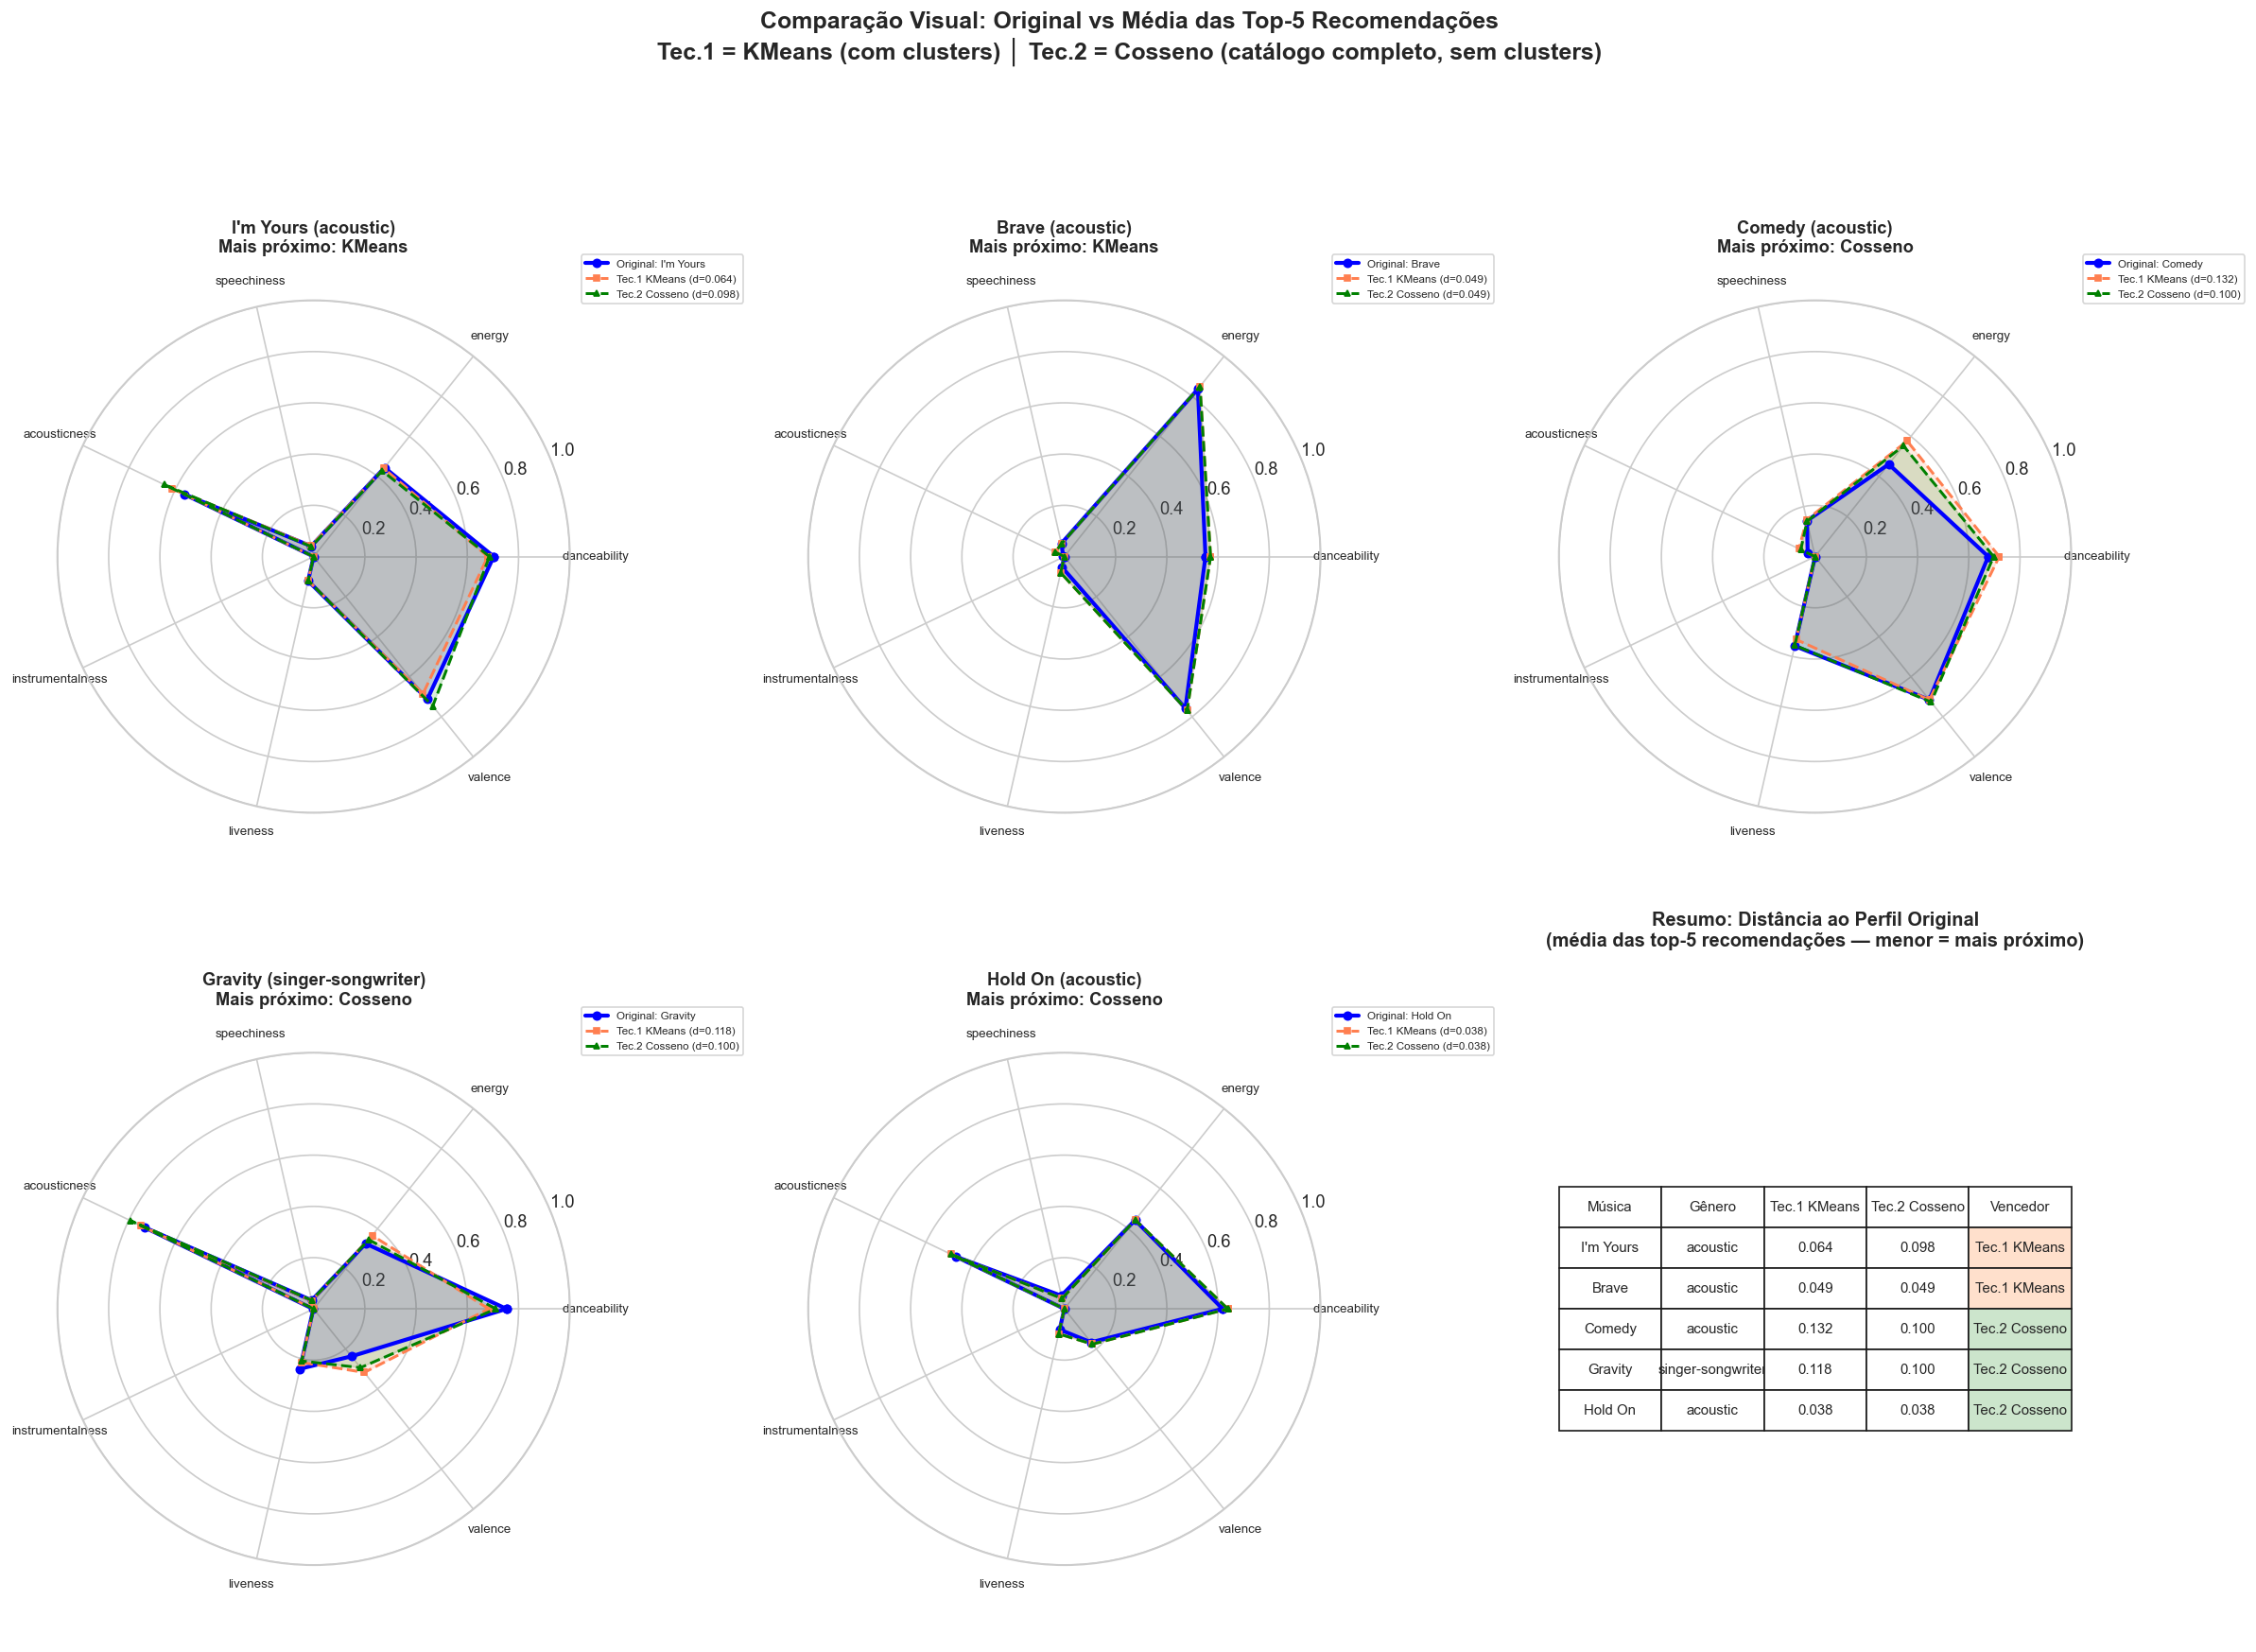


[1] Resumo — distância ao perfil original (média das top-5):

    Música          |   Tec.1 KMeans |  Tec.2 Cosseno | Vencedor
    ----------------+----------------+----------------+----------------
    I'm Yours       |         0.0640 |         0.0978 | Tec.1 KMeans
    Brave           |         0.0489 |         0.0489 | Tec.1 KMeans
    Comedy          |         0.1317 |         0.0999 | Tec.2 Cosseno
    Gravity         |         0.1179 |         0.1004 | Tec.2 Cosseno
    Hold On         |         0.0382 |         0.0382 | Tec.2 Cosseno

[2] Placar: KMeans 2 x 3 Cosseno
    Legenda: Tec.1 KMeans usa clusters | Tec.2 Cosseno busca no catálogo completo


In [47]:
# ============================================================
# 6.1 Comparação Visual: Radar Chart
#     Original vs MÉDIA das Top-5 KMeans vs MÉDIA das Top-5 Cosseno
# ============================================================
print("=" * 72)
print("6.1 COMPARAÇÃO VISUAL: ORIGINAL vs MÉDIA KMeans vs MÉDIA COSSENO")
print("    Tec.1 KMeans: usa clusters | Tec.2 Cosseno: catálogo completo")
print("=" * 72)

comparison_songs = [
    "I'm Yours",  # acoustic / pop
    "Brave",  # acoustic / pop-rock
    "Comedy",  # comedy (perfil peculiar)
    "Gravity",  # rock / alternative
    "Hold On",  # pop
]

radar_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
]
num_vars = len(radar_features)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

TOP_N_COMPARE = 5  # Número de recomendações para calcular a média

dist_summary = []

fig, axes = plt.subplots(2, 3, figsize=(20, 14), subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, song in enumerate(comparison_songs):
    ax = axes[i]

    # Encontrar música de referência
    matches = df[df["track_name"].str.lower() == song.lower()]
    if matches.empty:
        matches = df[df["track_name"].str.lower().str.contains(song.lower(), na=False)]
    if matches.empty:
        continue
    ref_idx = matches.sort_values("popularity", ascending=False).index[0]
    ref_info = df.loc[ref_idx]
    ref_values = ref_info[radar_features].values.tolist()

    # ── Técnica 1: KMeans (filtra por cluster + dist. Euclidiana) ──
    recs_km = recommend_kmeans(
        song, df, X_scaled, top_n=TOP_N_COMPARE, show_similarity=False
    )
    # ── Técnica 2: Cosseno (catálogo COMPLETO, SEM clusters) ──
    recs_cos = recommend_cosine(
        song, df, X_scaled, top_n=TOP_N_COMPARE, show_similarity=False
    )

    if recs_km is None or recs_cos is None:
        continue

    # MÉDIA das features das top-N recomendações de cada técnica
    km_indices = recs_km["original_index"].values
    cos_indices = recs_cos["original_index"].values

    km_avg_values = df.loc[km_indices, radar_features].mean().values.tolist()
    cos_avg_values = df.loc[cos_indices, radar_features].mean().values.tolist()

    # Distância Euclidiana entre perfil original e média das recomendações
    ref_arr = np.array(ref_values)
    km_dist = np.sqrt(np.sum((ref_arr - np.array(km_avg_values)) ** 2))
    cos_dist = np.sqrt(np.sum((ref_arr - np.array(cos_avg_values)) ** 2))

    dist_summary.append(
        {
            "Música": song,
            "Gênero": ref_info["track_genre"],
            "Dist_KMeans": km_dist,
            "Dist_Cosseno": cos_dist,
            "Vencedor": "Tec.1 KMeans" if km_dist < cos_dist else "Tec.2 Cosseno",
        }
    )

    # ── Plotar radar ──
    rv = ref_values + ref_values[:1]
    kv = km_avg_values + km_avg_values[:1]
    cv = cos_avg_values + cos_avg_values[:1]

    ax.fill(angles, rv, alpha=0.15, color="blue")
    ax.plot(
        angles,
        rv,
        "o-",
        color="blue",
        linewidth=2.5,
        markersize=5,
        label=f"Original: {song}",
    )

    ax.fill(angles, kv, alpha=0.15, color="coral")
    ax.plot(
        angles,
        kv,
        "s--",
        color="coral",
        linewidth=1.8,
        markersize=4,
        label=f"Tec.1 KMeans (d={km_dist:.3f})",
    )

    ax.fill(angles, cv, alpha=0.15, color="green")
    ax.plot(
        angles,
        cv,
        "^--",
        color="green",
        linewidth=1.8,
        markersize=4,
        label=f"Tec.2 Cosseno (d={cos_dist:.3f})",
    )

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_features, fontsize=8)
    ax.set_ylim(0, 1)
    winner = "KMeans" if km_dist < cos_dist else "Cosseno"
    ax.set_title(
        f"{song} ({ref_info['track_genre']})\nMais próximo: {winner}",
        fontsize=11,
        fontweight="bold",
        pad=15,
    )
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=7)

# Último subplot: tabela resumo
ax_table = axes[5]
ax_table.axis("off")
ax_table = fig.add_subplot(2, 3, 6)
ax_table.axis("off")

dist_df = pd.DataFrame(dist_summary)
cell_text = []
for _, row in dist_df.iterrows():
    cell_text.append(
        [
            row["Música"],
            row["Gênero"],
            f'{row["Dist_KMeans"]:.3f}',
            f'{row["Dist_Cosseno"]:.3f}',
            row["Vencedor"],
        ]
    )

table = ax_table.table(
    cellText=cell_text,
    colLabels=["Música", "Gênero", "Tec.1 KMeans", "Tec.2 Cosseno", "Vencedor"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.8)

# Colorir coluna do vencedor
for row_idx in range(1, len(cell_text) + 1):
    winner_val = cell_text[row_idx - 1][4]
    color = "#FFE0CC" if "KMeans" in winner_val else "#CCE5CC"
    table[row_idx, 4].set_facecolor(color)

ax_table.set_title(
    f"Resumo: Distância ao Perfil Original\n(média das top-{TOP_N_COMPARE} recomendações — menor = mais próximo)",
    fontsize=12,
    fontweight="bold",
    pad=20,
)

fig.suptitle(
    f"Comparação Visual: Original vs Média das Top-{TOP_N_COMPARE} Recomendações\n"
    "Tec.1 = KMeans (com clusters) │ Tec.2 = Cosseno (catálogo completo, sem clusters)",
    fontsize=15,
    fontweight="bold",
    y=1.04,
)
plt.tight_layout()
plt.savefig("resultados/19_radar_comparacao_tecnicas.png", dpi=150, bbox_inches="tight")
plt.show()

# Resumo textual
print(f"\n[1] Resumo — distância ao perfil original (média das top-{TOP_N_COMPARE}):\n")
print(f"    {'Música':15s} | {'Tec.1 KMeans':>14s} | {'Tec.2 Cosseno':>14s} | Vencedor")
print(f"    {'-'*15}-+-{'-'*14}-+-{'-'*14}-+-{'-'*15}")
for row in dist_summary:
    print(
        f"    {row['Música']:15s} | {row['Dist_KMeans']:>14.4f} | "
        f"{row['Dist_Cosseno']:>14.4f} | {row['Vencedor']}"
    )

km_wins = sum(1 for r in dist_summary if "KMeans" in r["Vencedor"])
cos_wins = len(dist_summary) - km_wins
print(f"\n[2] Placar: KMeans {km_wins} x {cos_wins} Cosseno")
print(
    f"    Legenda: Tec.1 KMeans usa clusters | Tec.2 Cosseno busca no catálogo completo"
)

In [48]:
# ============================================================
# 6.2 Avaliação quantitativa: Precision@K e Intra-List Similarity
# ============================================================
print("=" * 72)
print("6.2 AVALIAÇÃO QUANTITATIVA: PRECISION@K E INTRA-LIST SIMILARITY")
print("=" * 72)


def evaluate_precision_at_k(
    recommend_fn, df, features_scaled, sample_size=500, top_n=10
):
    """
    Calcula Precision@K usando gênero como proxy de relevância.
    Avalia sobre uma amostra aleatória de músicas.
    """
    np.random.seed(RANDOM_STATE)
    sample_indices = np.random.choice(len(df), size=sample_size, replace=False)

    precisions = []
    intra_similarities = []

    for idx in sample_indices:
        track_name = df.iloc[idx]["track_name"]
        ref_genre = df.iloc[idx]["track_genre"]

        try:
            recs = recommend_fn(
                track_name, df, features_scaled, top_n=top_n, show_similarity=False
            )
            if recs is None or recs.empty:
                continue

            # Precision@K: proporção do mesmo gênero
            same_genre = (recs["track_genre"] == ref_genre).sum()
            precision = same_genre / len(recs)
            precisions.append(precision)

            # Intra-List Similarity: coesão das recomendações
            rec_indices = recs["original_index"].values
            if len(rec_indices) >= 2:
                rec_features = features_scaled[rec_indices]
                pairwise_sim = cosine_similarity(rec_features)
                upper_triangle = pairwise_sim[np.triu_indices_from(pairwise_sim, k=1)]
                intra_similarities.append(upper_triangle.mean())

        except Exception:
            continue

    return np.array(precisions), np.array(intra_similarities)


print("[1] Avaliando Técnica 1: KMeans (filtra por cluster + dist. Euclidiana)...")
prec_kmeans, intra_kmeans = evaluate_precision_at_k(
    recommend_kmeans, df, X_scaled, sample_size=500, top_n=10
)

print("[2] Avaliando Técnica 2: Cosseno (catálogo completo, SEM clusters)...")
prec_cosine, intra_cosine = evaluate_precision_at_k(
    recommend_cosine, df, X_scaled, sample_size=500, top_n=10
)

print("\n[3] Avaliação concluída!")
print(f"    Tec.1 KMeans — Precision@10 média: {prec_kmeans.mean():.4f}")
print(f"    Tec.2 Cosseno — Precision@10 média: {prec_cosine.mean():.4f}")

6.2 AVALIAÇÃO QUANTITATIVA: PRECISION@K E INTRA-LIST SIMILARITY
[1] Avaliando Técnica 1: KMeans (filtra por cluster + dist. Euclidiana)...
[2] Avaliando Técnica 2: Cosseno (catálogo completo, SEM clusters)...

[3] Avaliação concluída!
    Tec.1 KMeans — Precision@10 média: 0.1244
    Tec.2 Cosseno — Precision@10 média: 0.1262


In [49]:
# ============================================================
# 6.3 Resultados comparativos consolidados
# ============================================================
print("=" * 72)
print("6.3 COMPARAÇÃO CONSOLIDADA")
print("    Tec.1 KMeans (usa clusters) vs Tec.2 Cosseno (sem clusters)")
print("=" * 72)

# --- Tabela 1: Métricas quantitativas ---
results = pd.DataFrame(
    {
        "Métrica": [
            "Precision@10 (média)",
            "Precision@10 (mediana)",
            "Precision@10 (desvio padrão)",
            "Intra-List Similarity (média)",
            "Silhouette Score",
        ],
        "Tec.1: KMeans (Euclidiana)": [
            f"{prec_kmeans.mean():.4f}",
            f"{np.median(prec_kmeans):.4f}",
            f"{prec_kmeans.std():.4f}",
            f"{intra_kmeans.mean():.4f}",
            f"{final_sil:.4f}",
        ],
        "Tec.2: Cosseno (s/ clusters)": [
            f"{prec_cosine.mean():.4f}",
            f"{np.median(prec_cosine):.4f}",
            f"{prec_cosine.std():.4f}",
            f"{intra_cosine.mean():.4f}",
            "N/A (não usa clusters)",
        ],
    }
)
results.index = range(1, len(results) + 1)
print("\n[1] Métricas de avaliação quantitativa:\n")
print(results.to_string(index=False))

# --- Tabela 2: Resumo da comparação visual (radar) ---
print("\n\n[2] Resumo da comparação visual (radar — dist. ao perfil original):\n")
dist_df_display = pd.DataFrame(dist_summary)
if not dist_df_display.empty:
    print(
        dist_df_display[
            ["Música", "Gênero", "Dist_KMeans", "Dist_Cosseno", "Vencedor"]
        ].to_string(index=False)
    )
    km_wins = sum(1 for r in dist_summary if "KMeans" in r["Vencedor"])
    cos_wins = len(dist_summary) - km_wins
    print(f"\n    Placar radar: KMeans {km_wins} x {cos_wins} Cosseno")

# --- Resumo geral ---
print("\n\n[3] Resumo geral:")
print(
    f"    Precision@10 — Tec.1 KMeans: {prec_kmeans.mean():.4f} | Tec.2 Cosseno: {prec_cosine.mean():.4f}"
)
diff_prec = abs(prec_kmeans.mean() - prec_cosine.mean())
print(
    f"    Diferença absoluta: {diff_prec:.4f} ({diff_prec/max(prec_kmeans.mean(), prec_cosine.mean())*100:.1f}%)"
)
print(
    f"    Intra-List Similarity — Tec.1 KMeans: {intra_kmeans.mean():.4f} | Tec.2 Cosseno: {intra_cosine.mean():.4f}"
)
print(
    f"\n    Lembrete: Tec.1 usa clusters KMeans | Tec.2 é independente (sem clusters)"
)

6.3 COMPARAÇÃO CONSOLIDADA
    Tec.1 KMeans (usa clusters) vs Tec.2 Cosseno (sem clusters)

[1] Métricas de avaliação quantitativa:

                      Métrica Tec.1: KMeans (Euclidiana) Tec.2: Cosseno (s/ clusters)
         Precision@10 (média)                     0.1244                       0.1262
       Precision@10 (mediana)                     0.0000                       0.0000
 Precision@10 (desvio padrão)                     0.2095                       0.2139
Intra-List Similarity (média)                     0.9217                       0.9330
             Silhouette Score                     0.1779       N/A (não usa clusters)


[2] Resumo da comparação visual (radar — dist. ao perfil original):

   Música            Gênero  Dist_KMeans  Dist_Cosseno      Vencedor
I'm Yours          acoustic     0.063961      0.097814  Tec.1 KMeans
    Brave          acoustic     0.048899      0.048899  Tec.1 KMeans
   Comedy          acoustic     0.131716      0.099863 Tec.2 Cosseno
  Gr

6.4 DISTRIBUIÇÃO DE PRECISION@K
    Tec.1 KMeans (com clusters) vs Tec.2 Cosseno (sem clusters)


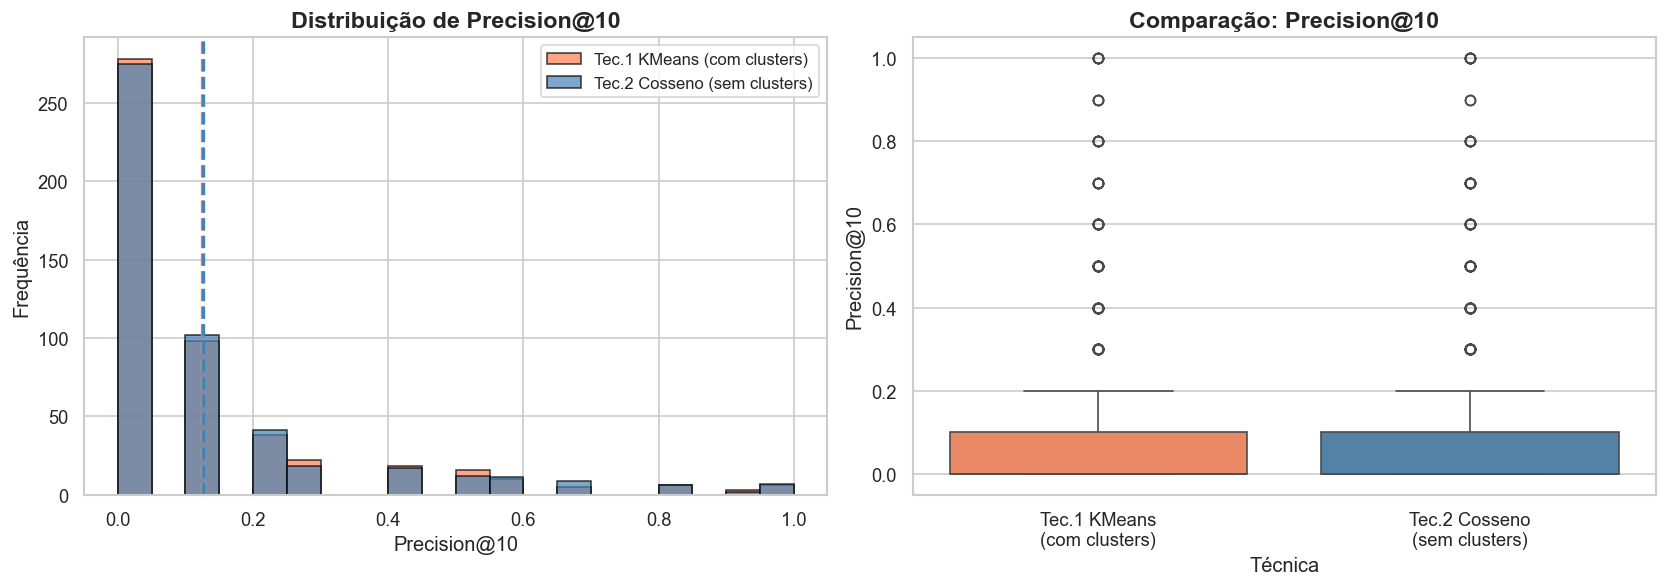

In [50]:
# ============================================================
# 6.4 Visualização da distribuição de Precision@K
# ============================================================
print("=" * 72)
print("6.4 DISTRIBUIÇÃO DE PRECISION@K")
print("    Tec.1 KMeans (com clusters) vs Tec.2 Cosseno (sem clusters)")
print("=" * 72)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramas sobrepostos
axes[0].hist(
    prec_kmeans,
    bins=20,
    alpha=0.7,
    color="coral",
    label="Tec.1 KMeans (com clusters)",
    edgecolor="black",
)
axes[0].hist(
    prec_cosine,
    bins=20,
    alpha=0.7,
    color="steelblue",
    label="Tec.2 Cosseno (sem clusters)",
    edgecolor="black",
)
axes[0].axvline(prec_kmeans.mean(), color="coral", linestyle="--", linewidth=2)
axes[0].axvline(prec_cosine.mean(), color="steelblue", linestyle="--", linewidth=2)
axes[0].set_xlabel("Precision@10", fontsize=12)
axes[0].set_ylabel("Frequência", fontsize=12)
axes[0].set_title("Distribuição de Precision@10", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=10)

# Boxplot comparativo
data_box = pd.DataFrame(
    {
        "Precision@10": np.concatenate([prec_kmeans, prec_cosine]),
        "Técnica": ["Tec.1 KMeans\n(com clusters)"] * len(prec_kmeans)
        + ["Tec.2 Cosseno\n(sem clusters)"] * len(prec_cosine),
    }
)
sns.boxplot(
    data=data_box,
    x="Técnica",
    y="Precision@10",
    ax=axes[1],
    palette=["coral", "steelblue"],
)
axes[1].set_title("Comparação: Precision@10", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("resultados/20_comparacao_precision.png", dpi=150, bbox_inches="tight")
plt.show()

6.5 ANÁLISE DE PRECISION@K POR GÊNERO
    Tec.1 KMeans (com clusters) vs Tec.2 Cosseno (sem clusters)
[1] Calculando Precision@K por gênero — Tec.1 KMeans (com clusters)...
[2] Calculando Precision@K por gênero — Tec.2 Cosseno (sem clusters)...


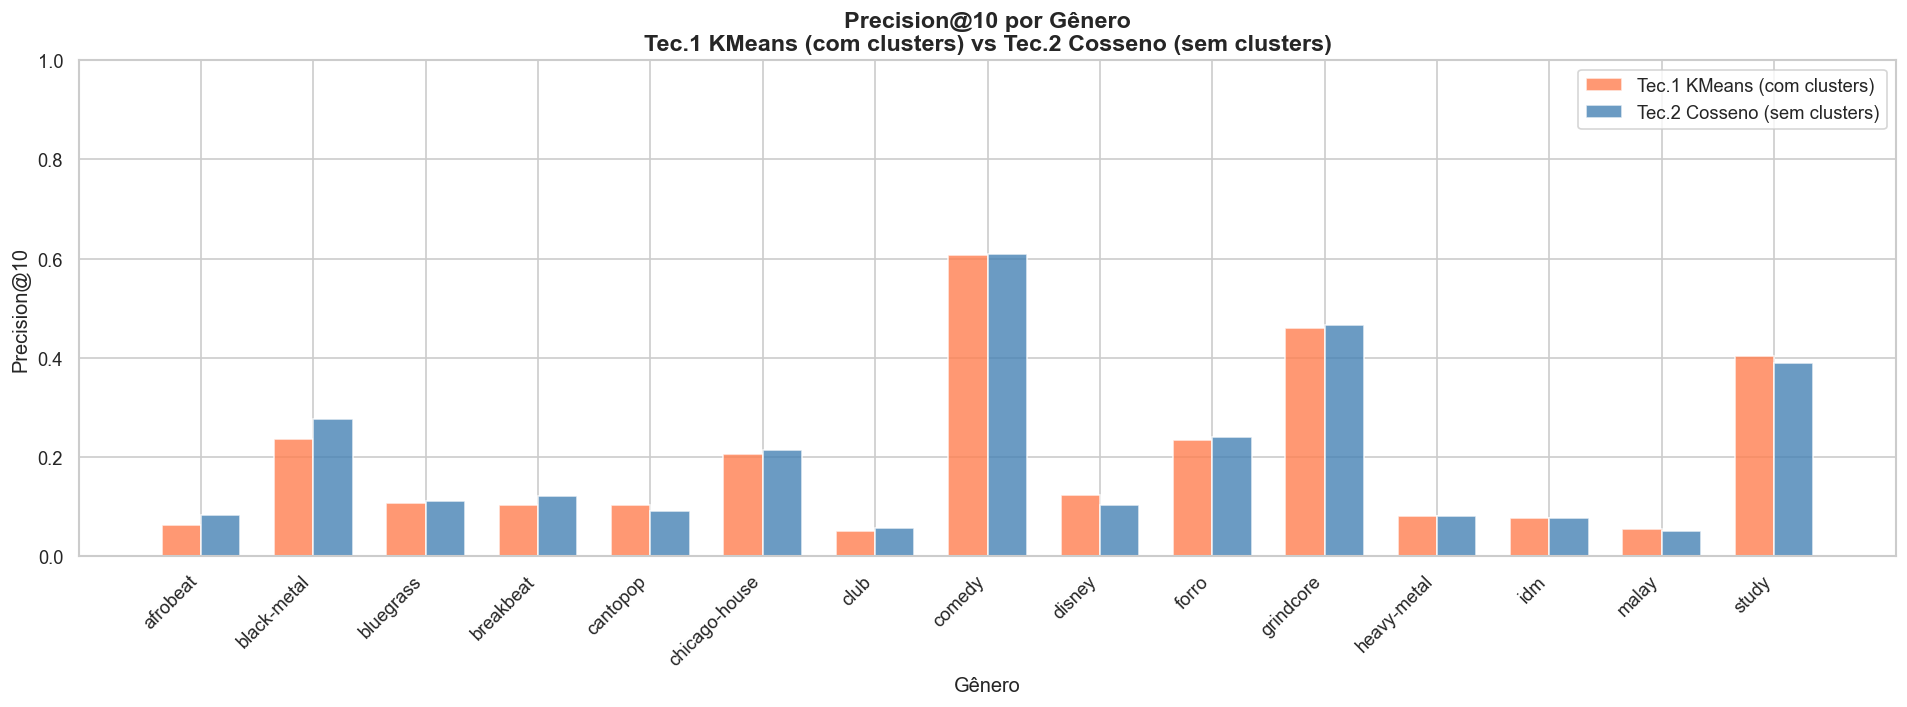


[3] Análise por gênero concluída!


In [51]:
# ============================================================
# 6.5 Análise por gênero: Precision@K por gênero
# ============================================================
print("=" * 72)
print("6.5 ANÁLISE DE PRECISION@K POR GÊNERO")
print("    Tec.1 KMeans (com clusters) vs Tec.2 Cosseno (sem clusters)")
print("=" * 72)


def precision_by_genre(
    recommend_fn, df, features_scaled, genres_sample=15, songs_per_genre=30, top_n=10
):
    """Calcula Precision@K médio para cada gênero."""
    np.random.seed(RANDOM_STATE)

    # Top gêneros por volume de músicas
    top_genres = df["track_genre"].value_counts().head(genres_sample).index.tolist()

    genre_precisions = {}
    for genre in top_genres:
        genre_df = df[df["track_genre"] == genre]
        sample_n = min(songs_per_genre, len(genre_df))
        sample_indices = np.random.choice(genre_df.index, size=sample_n, replace=False)

        precisions = []
        for idx in sample_indices:
            try:
                track_name = df.loc[idx, "track_name"]
                recs = recommend_fn(
                    track_name, df, features_scaled, top_n=top_n, show_similarity=False
                )
                if recs is not None and not recs.empty:
                    same_genre = (recs["track_genre"] == genre).sum()
                    precisions.append(same_genre / len(recs))
            except Exception:
                continue

        if precisions:
            genre_precisions[genre] = np.mean(precisions)

    return genre_precisions


print("[1] Calculando Precision@K por gênero — Tec.1 KMeans (com clusters)...")
genre_prec_kmeans = precision_by_genre(recommend_kmeans, df, X_scaled)

print("[2] Calculando Precision@K por gênero — Tec.2 Cosseno (sem clusters)...")
genre_prec_cosine = precision_by_genre(recommend_cosine, df, X_scaled)

# Barras agrupadas por gênero
genres = sorted(set(genre_prec_kmeans.keys()) & set(genre_prec_cosine.keys()))
x = np.arange(len(genres))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar(
    x - width / 2,
    [genre_prec_kmeans.get(g, 0) for g in genres],
    width,
    label="Tec.1 KMeans (com clusters)",
    color="coral",
    alpha=0.8,
)
bars2 = ax.bar(
    x + width / 2,
    [genre_prec_cosine.get(g, 0) for g in genres],
    width,
    label="Tec.2 Cosseno (sem clusters)",
    color="steelblue",
    alpha=0.8,
)

ax.set_xlabel("Gênero", fontsize=12)
ax.set_ylabel("Precision@10", fontsize=12)
ax.set_title(
    "Precision@10 por Gênero\nTec.1 KMeans (com clusters) vs Tec.2 Cosseno (sem clusters)",
    fontsize=14,
    fontweight="bold",
)
ax.set_xticks(x)
ax.set_xticklabels(genres, rotation=45, ha="right")
ax.legend(fontsize=11)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("resultados/21_precision_por_genero.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n[3] Análise por gênero concluída!")

### 6.6 Interpretação dos Resultados

#### Resumo das Técnicas
| Aspecto | Técnica 1: KMeans (Euclidiana) | Técnica 2: Cosseno |
|---------|-------------------------------|-------------------|
| **Usa clusters?** | Sim, filtra pelo cluster KMeans | Não, busca no catálogo completo |
| **Métrica de ranking** | Distância Euclidiana (dentro do cluster) | Similaridade de Cosseno (catálogo inteiro) |
| **Escopo de busca** | Restrito ao cluster da referência | Todo o dataset padronizado |
| **Visão** | Macro (famílias sonoras) | Micro (vizinhança individual) |
| **Força** | Coerência de perfil / homogeneidade | Granularidade na seleção |
| **Limitação** | Diversidade restrita ao cluster | Pode cruzar perfis sonoros |

#### Comparação Visual (Radar Charts — Média das Top-5)
A análise com radar charts de 5 músicas compara a **média das top-5 recomendações** de cada técnica contra o perfil original. Essa abordagem (média em vez de top-1) oferece uma visão mais robusta do comportamento típico de cada método.

- A **Técnica 1 (KMeans)** produz recomendações dentro de uma "família sonora" coerente.
- A **Técnica 2 (Cosseno)**, buscando no catálogo completo sem restrição de cluster, pode encontrar matches mais precisos em proporção de features.

#### Precision@K (Gênero como Proxy)
- A métrica Precision@10 mede a proporção de recomendações do **mesmo gênero** da referência.
- Os valores obtidos são modestos para ambas, pois o gênero é um **proxy imperfeito** — músicas de gêneros diferentes frequentemente compartilham features sonoras similares (Bogdanov et al., 2019).
- Gêneros com perfil sonoro **característico** (ex.: `classical`, `metal`) apresentam precisão mais alta.

#### Intra-List Similarity
- O KMeans tende a gerar listas mais **homogêneas** (maior coesão), natural dado o filtro por cluster.
- O Cosseno produz listas com **maior diversidade**, pois busca no catálogo completo.

#### Limitações
1. **Gênero como proxy**: Músicas de gêneros diferentes podem ser sonoramente similares (Bogdanov et al., 2019).
2. **Features limitadas**: Descritores do Spotify não capturam melodia, harmonia ou letra (Lartillot & Toiviainen, 2007).
3. **Cold-start parcial**: O sistema funciona apenas para músicas presentes no dataset.
4. **Avaliação offline**: Sem feedback de usuários reais, a avaliação é aproximada.

### Referências Adicionais
- Bogdanov, D., Won, M., Tovstogan, P., et al. (2019). *The MTG-Jamendo Dataset for Automatic Music Tagging*. ICML.
- Kunaver, M., & Požrl, T. (2017). *Diversity in Recommender Systems – A Survey*. Knowledge-Based Systems.
- Lartillot, O., & Toiviainen, P. (2007). *A Matlab Toolbox for Musical Feature Extraction From Audio*. DAFx.

---
## 7 - Conclusão

### 7.1 Principais Descobertas

1. **Clusters sonoros interpretáveis**: O KMeans com **K=7** identificou sete perfis sonoros distintos no dataset de 75.689 faixas. A escolha de K=7 foi fundamentada pela análise de Silhouette Score (seção 3.1): é o **maior valor de K com score elevado antes da queda** observada em K≥8, permitindo maior variabilidade de perfis sem fragmentação excessiva.

2. **Complementaridade das técnicas (independentes entre si)**:
   - **Técnica 1 — KMeans (Euclidiana)**: Utiliza os clusters KMeans para pré-filtrar candidatos, depois ordena por distância Euclidiana dentro do cluster. Gera listas homogêneas dentro de uma "família sonora".
   - **Técnica 2 — Cosseno**: Técnica **completamente independente** que busca no catálogo completo por similaridade de cosseno, **sem usar clusters**. Pode encontrar matches mais precisos em proporção de features.

3. **Precisão por gênero**: Ambas as técnicas apresentam melhor desempenho em gêneros com perfil sonoro característico e bem definido (ex.: `classical`, `metal`) do que em gêneros com alta variação interna (ex.: `pop`, `rock`).

4. **Limitação do gênero como proxy**: A métrica Precision@K usando gênero como referência produz valores modestos para ambas as técnicas, confirmando que features de áudio capturam dimensões sonoras que não se alinham perfeitamente com rótulos de gênero — uma limitação conhecida na literatura (Bogdanov et al., 2019).

### 7.2 Resposta ao Problema Proposto

Sim, **é possível construir um sistema de recomendação de músicas utilizando exclusivamente atributos de áudio**, sem depender de dados de interação do usuário. As duas técnicas não supervisionadas — **KMeans com Distância Euclidiana** e **Similaridade de Cosseno** — se complementam, oferecendo visões macro (clusters) e micro (similaridade individual) da similaridade musical. Crucialmente, a Técnica 2 (Cosseno) opera de forma **completamente independente** da Técnica 1, utilizando apenas o dataset padronizado.

### 7.3 Sugestões de Melhorias Futuras

| Melhoria | Descrição |
|----------|----------|
| **Filtragem Colaborativa** | Incorporar dados de interação do usuário (playlists, histórico) para complementar o content-based |
| **NLP em letras** | Utilizar processamento de linguagem natural nas letras para capturar similaridade temática |
| **Deep Learning** | Aplicar autoencoders para aprender representações latentes mais ricas |
| **Avaliação A/B** | Realizar testes com usuários reais para validar a qualidade percebida |
| **Ensemble** | Combinar os rankings das duas técnicas com pesos ajustáveis |

In [52]:
# ============================================================
# Salvar dataset enriquecido com clusters
# ============================================================
print("=" * 72)
print("SALVANDO ARTEFATOS FINAIS")
print("=" * 72)

df.to_csv("spotify_with_clusters.csv", index=False)

print(f"\n[1] Dataset com clusters salvo: spotify_with_clusters.csv")
print(f"    Shape final: {df.shape} | Coluna adicionada: cluster (K={OPTIMAL_K})")

print(f"\n[2] Notebook finalizado com sucesso!")
print(f"\n    Técnicas comparadas:")
print(f"    - Técnica 1: KMeans + Distância Euclidiana (USA clusters, K={OPTIMAL_K})")
print(f"    - Técnica 2: Similaridade de Cosseno (INDEPENDENTE, sem clusters)")

print(f"\n[3] Artefatos gerados em resultados/:")
artifacts = [
    "11_distribuicao_features.png",
    "12_correlacao_features.png",
    "13_pca_variancia.png",
    "14_elbow_silhouette.png",
    "14b_validacao_k.png",
    "15_clusters_pca2d.png",
    "16_cluster_profiles_heatmap.png",
    "17_cluster_radar.png",
    "18_generos_por_cluster.png",
    "19_radar_comparacao_tecnicas.png",
    "20_comparacao_precision.png",
    "21_precision_por_genero.png",
]
for a in artifacts:
    print(f"    - {a}")

SALVANDO ARTEFATOS FINAIS

[1] Dataset com clusters salvo: spotify_with_clusters.csv
    Shape final: (75689, 21) | Coluna adicionada: cluster (K=7)

[2] Notebook finalizado com sucesso!

    Técnicas comparadas:
    - Técnica 1: KMeans + Distância Euclidiana (USA clusters, K=7)
    - Técnica 2: Similaridade de Cosseno (INDEPENDENTE, sem clusters)

[3] Artefatos gerados em resultados/:
    - 11_distribuicao_features.png
    - 12_correlacao_features.png
    - 13_pca_variancia.png
    - 14_elbow_silhouette.png
    - 14b_validacao_k.png
    - 15_clusters_pca2d.png
    - 16_cluster_profiles_heatmap.png
    - 17_cluster_radar.png
    - 18_generos_por_cluster.png
    - 19_radar_comparacao_tecnicas.png
    - 20_comparacao_precision.png
    - 21_precision_por_genero.png
